<a href="https://colab.research.google.com/github/hamidb201214-svg/Lectures/blob/main/M3_4_GNN_GCN_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

Recently, deep learning on graphs has emerged to one of the hottest research fields in the deep learning community.
Here, **Graph Neural Networks (GNNs)** aim to generalize classical deep learning concepts to irregular structured data (in contrast to images or texts) and to enable neural networks to reason about objects and their relations.

This tutorial will introduce you to some fundamental concepts regarding deep learning on graphs via Graph Neural Networks based on the **[PyTorch Geometric (PyG) library](https://github.com/rusty1s/pytorch_geometric)**.
PyTorch Geometric is an extension library to the popular deep learning framework [PyTorch](https://pytorch.org/), and consists of various methods and utilities to ease the implementation of Graph Neural Networks.

### Types of Graph Neural Networks (GNNs)

GNNs are a group of neural networks designed for data structured as graphs. Each type has its own special features and ways of working. Here's a quick look at some common types:

- **Graph Convolutional Networks (GCNs)**: GCNs update the features of each node by pulling information from neighboring nodes. They use graph convolution operations to do this.

- **Graph Attention Networks (GATs)**: GATs use attention mechanisms, which means they can pay more attention to certain nodes than others. This helps GATs focus on the most important information in the graph.

- **GraphSAGE**: GraphSAGE samples a fixed number of neighbors for each node, then combines their features. This method helps in dealing with large graphs by focusing on a node's immediate neighborhood.

- **Graph Isomorphism Network (GIN)**: GINs work well with both directed and undirected graphs. They use multiple steps to gather neighborhood information and a special type of neural network (MLP) to process it.

- **Graph Neural Networks with Recurrent Units (GRUs)**: GRUs are great for graphs that change over time. They are used in scenarios where the graph data has a time component, like a sequence.

- **Graph Wavelet Neural Networks (GWNNs)**: GWNNs use graph wavelet transforms to analyze graphs.They can capture both local and overall structures in a graph effectively.

- **Graph Autoencoders**: These models learn to compress graph data and then reconstruct it. Useful for tasks like generating graphs, detecting unusual patterns, and learning useful representations of graph data.

- **Graph Generative Models**: These models are all about creating new graphs similar to ones they've seen during training. Includes models like Graph Variational Autoencoders (Graph-VAEs), Graph Generative Adversarial Networks (Graph-GANs), and Graph Neural Networks for Graph Generation (GraphRNN).


![](https://raw.githubusercontent.com/aaubs/ds-master/main/data/Images/Graph.png)

## Understanding Graph Neural Networks (GNNs)
Graph Neural Networks (GNNs) are specialized in handling data represented as a graph or network. The fundamental concept of GNNs revolves around disseminating information across this graph. Nodes, or points in the network, continuously update their features by considering the features of their connected neighbors. This iterative process equips GNNs with the capability to develop nuanced and contextually relevant node representations, effectively capturing the complex dynamics of both local connections and the overarching graph structure.

Each GNN comprises multiple layers, and each layer is tasked with two primary functions: message passing and aggregation. In the message-passing phase, nodes actively collect information from their adjacent nodes. Following this, the aggregation step involves the assimilation of this accumulated information to refine each node's features. By repeating these steps across successive layers, the GNN progressively becomes adept at recognizing and interpreting increasingly intricate patterns within the graph.

**Information Propagation**:
  - GNNs spread information across a graph.
  - Each node (point) updates its features by looking at its neighbors' features.
  - This helps GNNs learn meaningful features that reflect both local and global connections in the graph.

**Multiple Layers**:
  - A GNN is composed of several layers.
  - Each layer performs two main steps: message passing and aggregation.

    - **Message Passing**: In this step, each node collects information from its directly connected neighbors.

    - **Aggregation**: Here, a node combines the gathered information to refine its own features.
> This combination reflects the characteristics of its neighboring nodes.

**Iterative Process**:
- These steps (message passing and aggregation) are repeated across the layers.
- As the process continues through more layers, the GNN becomes capable of understanding increasingly complex graph patterns.


![](https://editor.analyticsvidhya.com/uploads/594271b.jpg)

Following [Kipf et al. (2017)](https://arxiv.org/abs/1609.02907), let's dive into the world of GNNs by looking at a simple graph-structured example, the well-known [**Zachary's karate club network**](https://en.wikipedia.org/wiki/Zachary%27s_karate_club). This graph describes a social network of 34 members of a karate club and documents links between members who interacted outside the club. Here, we are interested in detecting communities that arise from the member's interaction.

## PyTorch Geometric Library

PyTorch Geometric (PyG) is an extension library for PyTorch. It provides useful primitives to develop Graph Deep Learning models, including various graph neural network layers and a large number of benchmark datasets.

Don't worry if you don't understand some concepts such as `GCNConv` -- we will cover all of them in the future lectures :)

This tutorial is adapted from https://colab.research.google.com/drive/1h3-vJGRVloF5zStxL5I0rSy4ZUPNsjy8?usp=sharing#scrollTo=ci-LpZWhRJoI by [Matthias Fey](https://rusty1s.github.io/#/)


In [1]:
import torch
print("PyTorch has version {}".format(torch.__version__))

PyTorch has version 2.10.0+cu128


## Setup

The installation of PyG on Colab can be a little bit tricky. Execute the cell below -- in case of issues, more information can be found on the [PyG's installation page](https://pytorch-geometric.readthedocs.io/en/latest/notes/installation.html).

In [2]:
import torch

torch_ver = torch.__version__.split("+")[0]          # e.g. 2.6.0
torch_mm = ".".join(torch_ver.split(".")[:2]) + ".0" # e.g. 2.6.0 wheel base
cuda_ver = torch.version.cuda                         # e.g. 12.4
cuda_tag = "cpu" if cuda_ver is None else "cu" + cuda_ver.replace(".", "")

print("Torch:", torch.__version__)
print("CUDA :", torch.version.cuda)
print("Wheel:", f"https://data.pyg.org/whl/torch-{torch_mm}+{cuda_tag}.html")

Torch: 2.10.0+cu128
CUDA : 12.8
Wheel: https://data.pyg.org/whl/torch-2.10.0+cu128.html


In [3]:
!pip install -q pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-{torch_mm}+{cuda_tag}.html
!pip install -q torch-geometric

ERROR: Could not find a version that satisfies the requirement pyg_lib (from versions: none)
ERROR: No matching distribution found for pyg_lib
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 48.1 MB/s eta 0:00:00


## Visualization

In [4]:
# Helper function for visualization.
%matplotlib inline
import torch
import networkx as nx
import matplotlib.pyplot as plt

# Visualization function for NX graph or PyTorch tensor
def visualize(h, color, epoch=None, loss=None):
    plt.figure(figsize=(7,7))
    plt.xticks([])
    plt.yticks([])

    if torch.is_tensor(h):
        h = h.detach().cpu().numpy()
        plt.scatter(h[:, 0], h[:, 1], s=140, c=color, cmap="Set2")
        if epoch is not None and loss is not None:
            plt.xlabel(f'Epoch: {epoch}, Loss: {loss.item():.4f}', fontsize=16)
    else:
        nx.draw_networkx(G, pos=nx.spring_layout(G, seed=42), with_labels=False,
                         node_color=color, cmap="Set2")
    plt.show()

## Dataset

PyTorch Geometric provides an easy access to the dataset via the [`torch_geometric.datasets`](https://pytorch-geometric.readthedocs.io/en/latest/modules/datasets.html#torch_geometric.datasets) subpackage:

In [5]:
from torch_geometric.datasets import KarateClub

dataset = KarateClub()
print(f'Dataset: {dataset}:')
print('======================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

Dataset: KarateClub():
Number of graphs: 1
Number of features: 34
Number of classes: 4


After initializing the [`KarateClub`](https://pytorch-geometric.readthedocs.io/en/latest/modules/datasets.html#torch_geometric.datasets.KarateClub) dataset, we first can inspect some of its properties.
For example, we can see that this dataset holds exactly **one graph**, and that each node in this dataset is assigned a **34-dimensional feature vector** (which uniquely describes the members of the karate club).
Furthermore, the graph holds exactly **4 classes**, which represent the community each node belongs to.

Let's now look at the underlying graph in more detail:

In [6]:
data = dataset[0]  # Get the first graph object.

print(data)
print('==============================================================')

# Gather some statistics about the graph.
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Average node degree: {data.num_edges / data.num_nodes:.2f}')
print(f'Number of training nodes: {data.train_mask.sum()}')
print(f'Training node label rate: {int(data.train_mask.sum()) / data.num_nodes:.2f}')
print(f'Contains isolated nodes: {data.contains_isolated_nodes()}')
print(f'Contains self-loops: {data.contains_self_loops()}')
print(f'Is undirected: {data.is_undirected()}')

Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])
Number of nodes: 34
Number of edges: 156
Average node degree: 4.59
Number of training nodes: 4
Training node label rate: 0.12
Contains isolated nodes: False
Contains self-loops: False
Is undirected: True


/tmp/ipython-input-2338026956.py:12: UserWarning: 'contains_isolated_nodes' is deprecated, use 'has_isolated_nodes' instead
  print(f'Contains isolated nodes: {data.contains_isolated_nodes()}')
/tmp/ipython-input-2338026956.py:13: UserWarning: 'contains_self_loops' is deprecated, use 'has_self_loops' instead
  print(f'Contains self-loops: {data.contains_self_loops()}')


## Data

Each graph in PyTorch Geometric is represented by a single [`Data`](https://pytorch-geometric.readthedocs.io/en/latest/modules/data.html#torch_geometric.data.Data) object, which holds all the information to describe its graph representation.
We can print the data object anytime via `print(data)` to receive a short summary about its attributes and their shapes:
```
Data(edge_index=[2, 156], x=[34, 34], y=[34], train_mask=[34])
```
We can see that this `data` object holds 4 attributes:
(1) The `edge_index` property holds the information about the **graph connectivity**, *i.e.*, a tuple of source and destination node indices for each edge.
PyG further refers to (2) **node features** as `x` (each of the 34 nodes is assigned a 34-dim feature vector), and to (3) **node labels** as `y` (each node is assigned to exactly one class).
(4) There also exists an additional attribute called `train_mask`, which describes for which nodes we already know their community assigments.
In total, we are only aware of the ground-truth labels of 34 nodes, and the task is to infer the community assignment for the remaining nodes.

The `data` object offers utility functions to discern basic properties of the underlying graph. For instance, it can detect the presence of isolated nodes (nodes with no connecting edges). It also identifies if the graph contains self-loops, which means an edge where both ends connect to the same node, denoted as \\((v, v) \in \mathcal{E}\\).


In [7]:
edge_index = data.edge_index
print(edge_index.t())

tensor([[ 0,  1],
        [ 0,  2],
        [ 0,  3],
        [ 0,  4],
        [ 0,  5],
        [ 0,  6],
        [ 0,  7],
        [ 0,  8],
        [ 0, 10],
        [ 0, 11],
        [ 0, 12],
        [ 0, 13],
        [ 0, 17],
        [ 0, 19],
        [ 0, 21],
        [ 0, 31],
        [ 1,  0],
        [ 1,  2],
        [ 1,  3],
        [ 1,  7],
        [ 1, 13],
        [ 1, 17],
        [ 1, 19],
        [ 1, 21],
        [ 1, 30],
        [ 2,  0],
        [ 2,  1],
        [ 2,  3],
        [ 2,  7],
        [ 2,  8],
        [ 2,  9],
        [ 2, 13],
        [ 2, 27],
        [ 2, 28],
        [ 2, 32],
        [ 3,  0],
        [ 3,  1],
        [ 3,  2],
        [ 3,  7],
        [ 3, 12],
        [ 3, 13],
        [ 4,  0],
        [ 4,  6],
        [ 4, 10],
        [ 5,  0],
        [ 5,  6],
        [ 5, 10],
        [ 5, 16],
        [ 6,  0],
        [ 6,  4],
        [ 6,  5],
        [ 6, 16],
        [ 7,  0],
        [ 7,  1],
        [ 7,  2],
        [ 

## Edge Index

By printing `edge_index`, we can further understand how PyG represents graph connectivity internally.
We can see that for each edge, `edge_index` holds a tuple of two node indices, where the first value describes the node index of the source node and the second value describes the node index of the destination node of an edge.

This representation is known as the **COO format (coordinate format)** commonly used for representing sparse matrices.
Instead of holding the adjacency information in a dense representation $\mathbf{A} \in \{ 0, 1 \}^{|\mathcal{V}| \times |\mathcal{V}|}$, PyG represents graphs sparsely, which refers to only holding the coordinates/values for which entries in $\mathbf{A}$ are non-zero.

We can further visualize the graph by converting it to the `networkx` library format, which implements, in addition to graph manipulation functionalities, powerful tools for visualization:

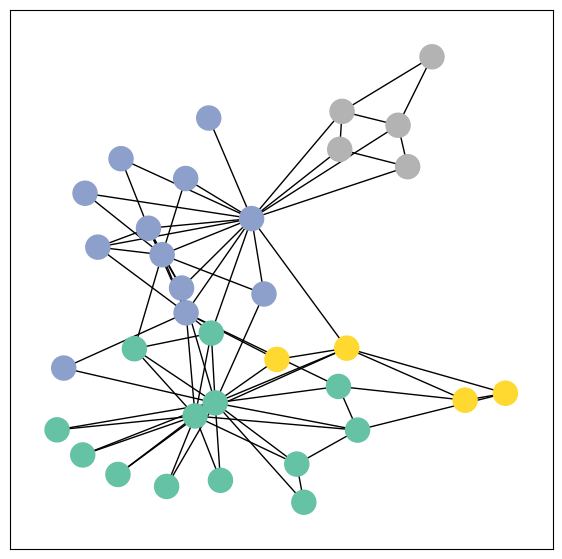

In [8]:
from torch_geometric.utils import to_networkx

G = to_networkx(data, to_undirected=True)
visualize(G, color=data.y)

## Implementing Graph Neural Networks

After learning about PyG's data handling, it's time to implement our first Graph Neural Network!

For this, we will use one of the most simple GNN operators, the **GCN layer** ([Kipf et al. (2017)](https://arxiv.org/abs/1609.02907)).

PyG implements this layer via [`GCNConv`](https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html#torch_geometric.nn.conv.GCNConv), which can be executed by passing in the node feature representation `x` and the COO graph connectivity representation `edge_index`.

With this, we are ready to create our first Graph Neural Network by defining our network architecture in a `torch.nn.Module` class:

In [9]:
import torch
from torch.nn import Linear
from torch_geometric.nn import GCNConv


class GCN(torch.nn.Module):
    def __init__(self):
        super(GCN, self).__init__()
        torch.manual_seed(12345)
        self.conv1 = GCNConv(dataset.num_features, 4)
        self.conv2 = GCNConv(4, 4)
        self.conv3 = GCNConv(4, 2)
        self.classifier = Linear(2, dataset.num_classes)

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index)
        h = h.tanh()
        h = self.conv2(h, edge_index)
        h = h.tanh()
        h = self.conv3(h, edge_index)
        h = h.tanh()  # Final GNN embedding space.

        # Apply a final (linear) classifier.
        out = self.classifier(h)

        return out, h

model = GCN()
print(model)

GCN(
  (conv1): GCNConv(34, 4)
  (conv2): GCNConv(4, 4)
  (conv3): GCNConv(4, 2)
  (classifier): Linear(in_features=2, out_features=4, bias=True)
)


Here, we first initialize all of our building blocks in `__init__` and define the computation flow of our network in `forward`.
We first define and stack **three graph convolution layers**, which corresponds to aggregating 3-hop neighborhood information around each node (all nodes up to 3 "hops" away). Imagine you are at a party and you want to know how popular someone is. You could just ask the people around you (your 1-hop neighbors), but that might not give you the whole picture. To get a better sense of their popularity, you could also ask their friends (your 2-hop neighbors), and even ask their friends' friends (your 3-hop neighbors).

Graph neural networks (GNNs) work in a similar way. They are able to learn information about nodes in a graph by aggregating information from their neighbors, not just their 1-hop neighbors but also their 2-hop and 3-hop neighbors. This allows them to learn more complex patterns in the graph data, which can be useful for tasks such as social network analysis, knowledge graph completion, and molecular property prediction.

In addition, the `GCNConv` layers reduce the node feature dimensionality to $2$, *i.e.*, $34 \rightarrow 4 \rightarrow 4 \rightarrow 2$. Each `GCNConv` layer is enhanced by a [tanh](https://pytorch.org/docs/stable/generated/torch.nn.Tanh.html?highlight=tanh#torch.nn.Tanh) non-linearity.

After that, we apply a single linear transformation ([`torch.nn.Linear`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html?highlight=linear#torch.nn.Linear)) that acts as a classifier to map our nodes to 1 out of the 4 classes/communities.

We return both the output of the final classifier as well as the final node embeddings produced by our GNN.
We proceed to initialize our final model via `GCN()`, and printing our model produces a summary of all its used sub-modules.

Embedding shape: [34, 2]


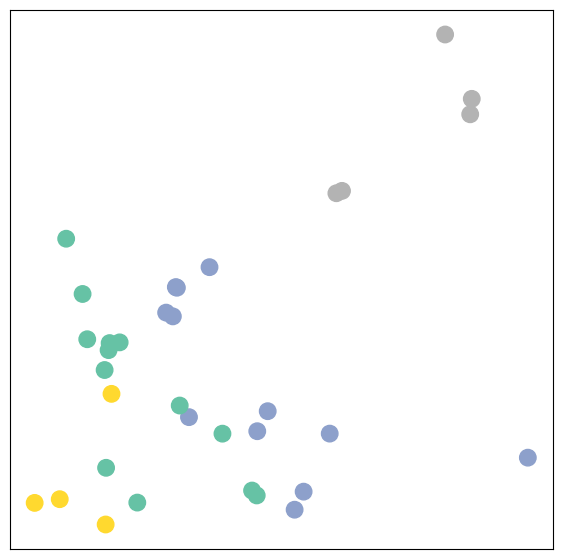

In [10]:
model = GCN()

_, h = model(data.x, data.edge_index)
print(f'Embedding shape: {list(h.shape)}')

visualize(h, color=data.y)

Remarkably, even before training the weights of our model, the model produces an embedding of nodes that closely resembles the community-structure of the graph.
Nodes of the same color (community) are already closely clustered together in the embedding space, although the weights of our model are initialized **completely at random** and we have not yet performed any training so far!
This leads to the conclusion that GNNs introduce a strong inductive bias, leading to similar embeddings for nodes that are close to each other in the input graph. In the context of GNNs, the inductive bias is related to the structure and connectivity of the graph itself. That means that even with randomly initialized weights and without any training, the GNN's embeddings already show a tendency to cluster nodes of the same community closely together in the embedding space. This implies that the GNN has a built-in bias towards modeling the community structure inherent in the graph.


### Training on the Karate Club Network

But can we do better? Let's look at an example on how to train our network parameters based on the knowledge of the community assignments of 4 nodes in the graph (one for each community):

Since everything in our model is differentiable and parameterized, we can add some labels, train the model and observe how the embeddings react.
Here, we make use of a semi-supervised or transductive learning procedure: We simply train against one node per class, but are allowed to make use of the complete input graph data.

Training our model is very similar to any other PyTorch model.
In addition to defining our network architecture, we define a loss criterion (here, [`CrossEntropyLoss`](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)) and initialize a stochastic gradient optimizer (here, [`Adam`](https://pytorch.org/docs/stable/optim.html?highlight=adam#torch.optim.Adam)).
After that, we perform multiple rounds of optimization, where each round consists of a forward and backward pass to compute the gradients of our model parameters w.r.t. to the loss derived from the forward pass.
If you are not new to PyTorch, this scheme should appear familar to you.
Otherwise, the PyTorch docs provide [a good introduction on how to train a neural network in PyTorch](https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html#define-a-loss-function-and-optimizer).

Note that our semi-supervised learning scenario is achieved by the following line:
```
loss = criterion(out[data.train_mask], data.y[data.train_mask])
```
While we compute node embeddings for all of our nodes, we **only make use of the training nodes for computing the loss**.
Here, this is implemented by filtering the output of the classifier `out` and ground-truth labels `data.y` to only contain the nodes in the `train_mask`.

Let us now start training and see how our node embeddings evolve over time (best experienced by explicitely running the code):

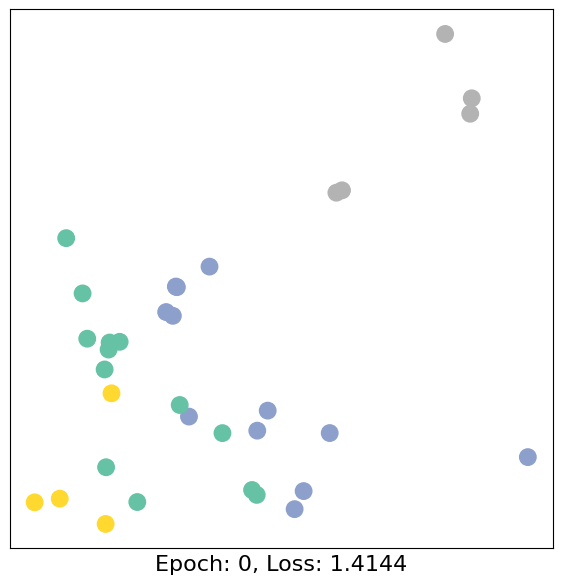

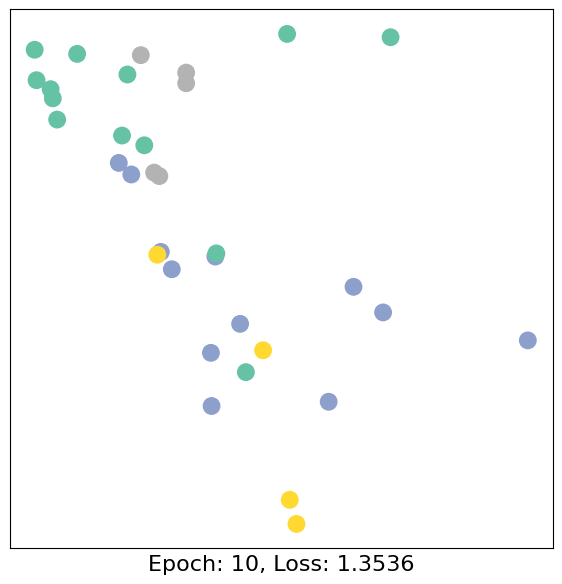

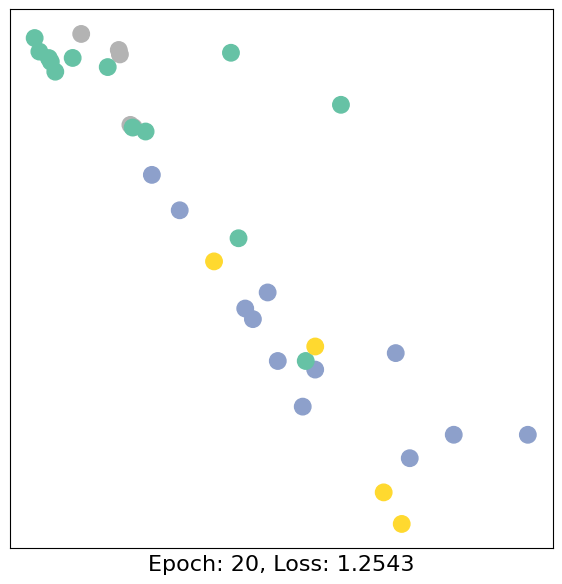

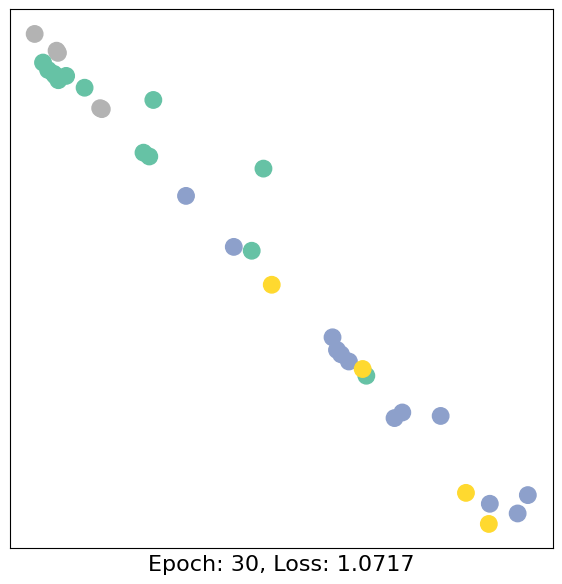

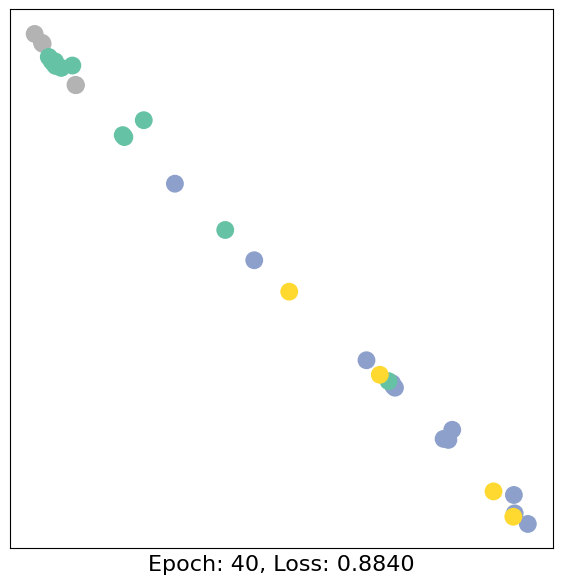

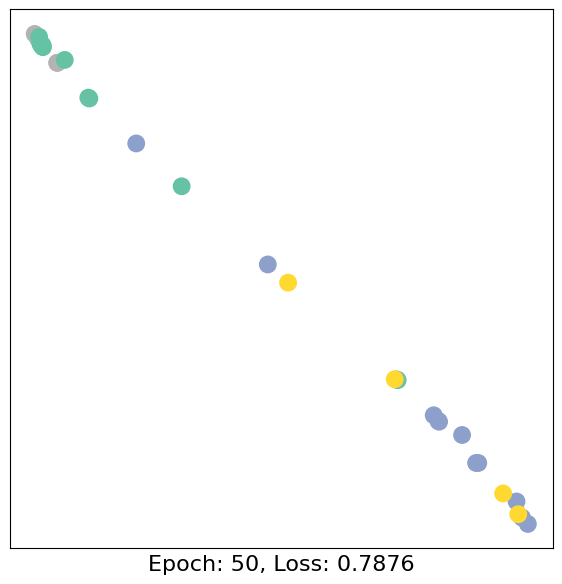

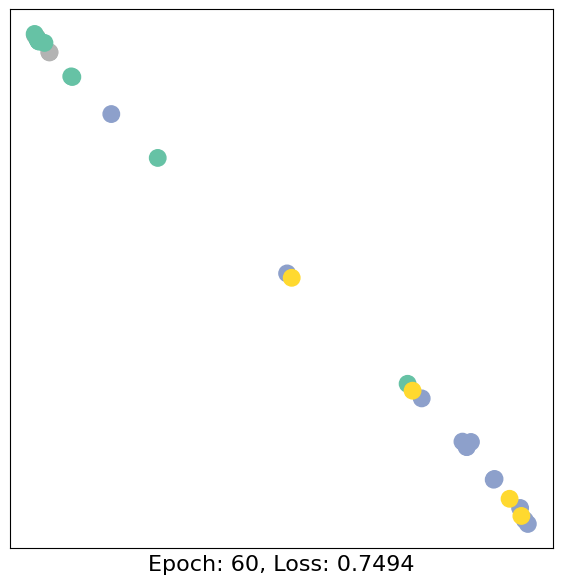

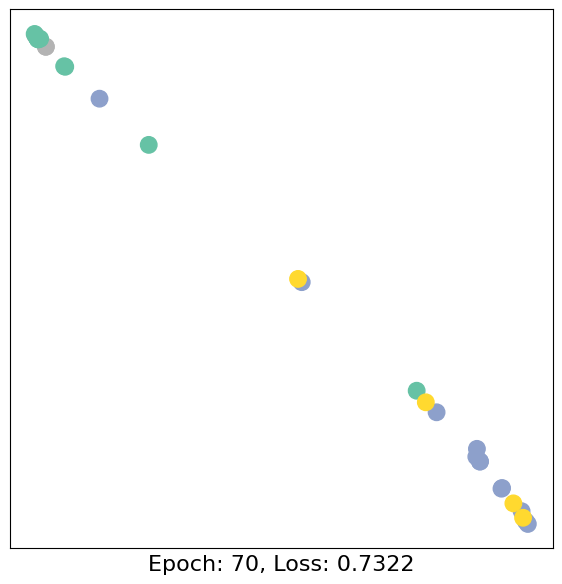

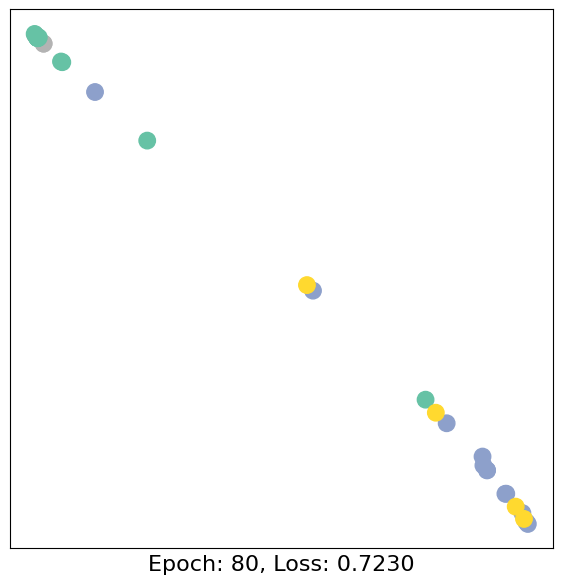

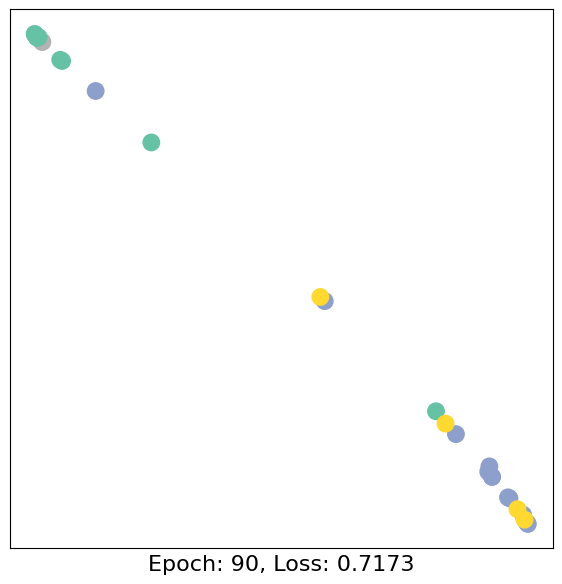

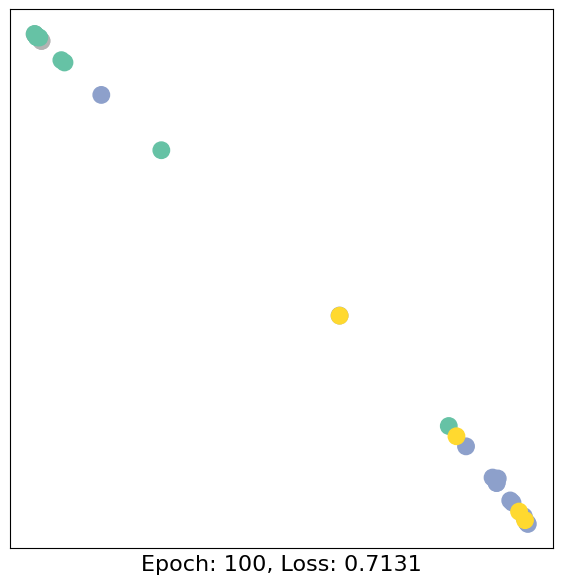

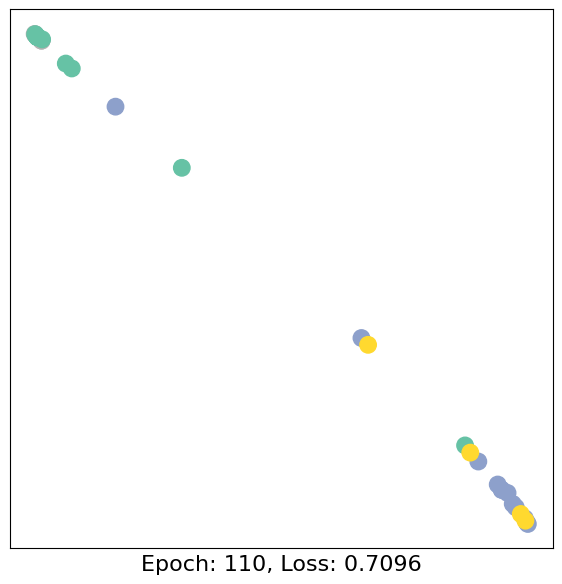

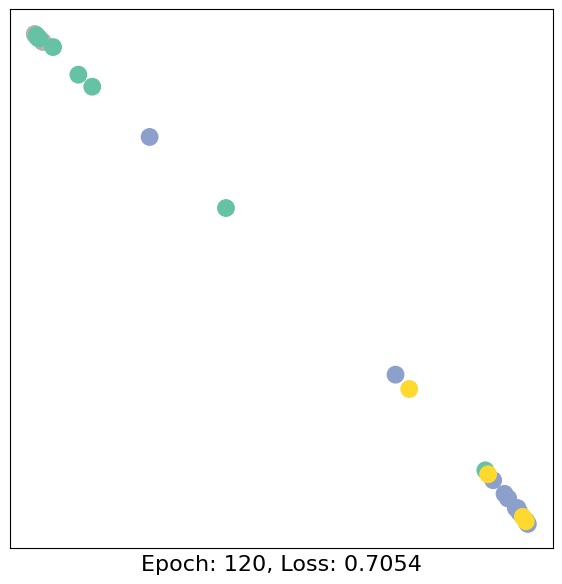

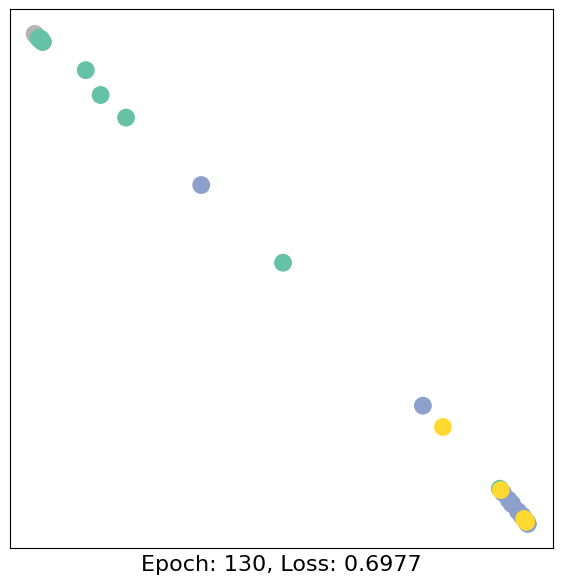

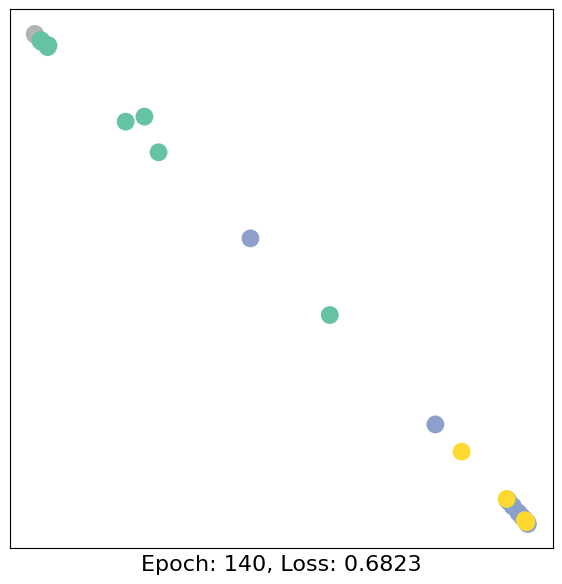

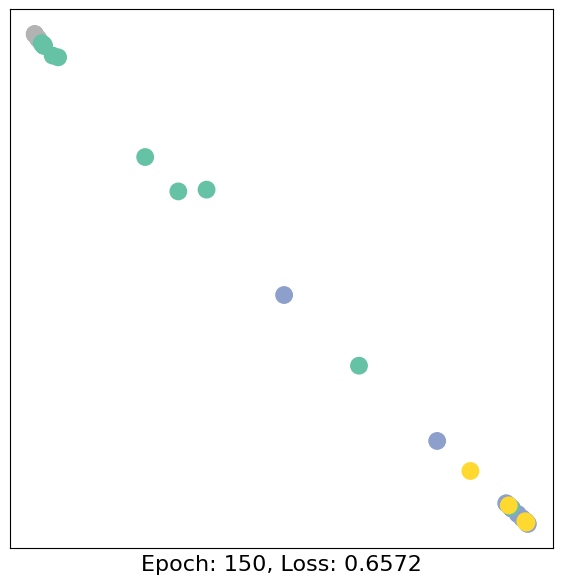

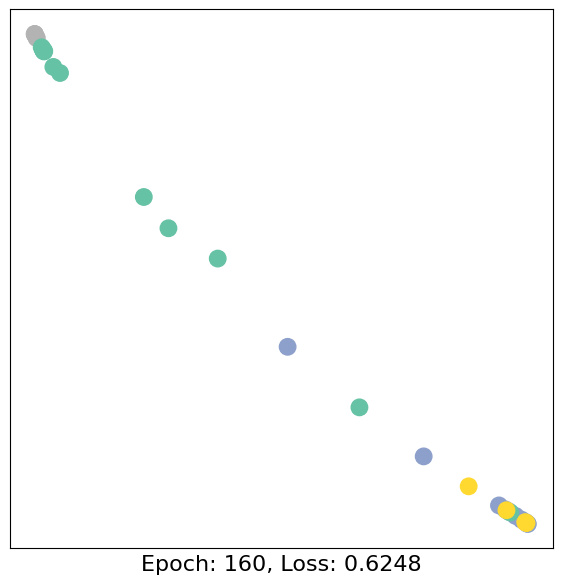

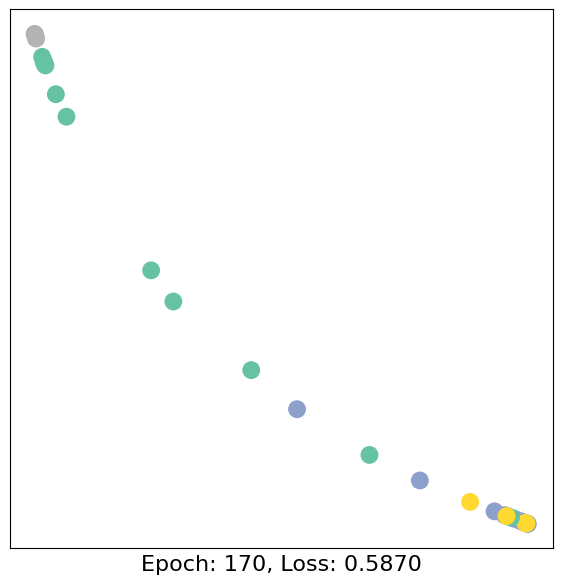

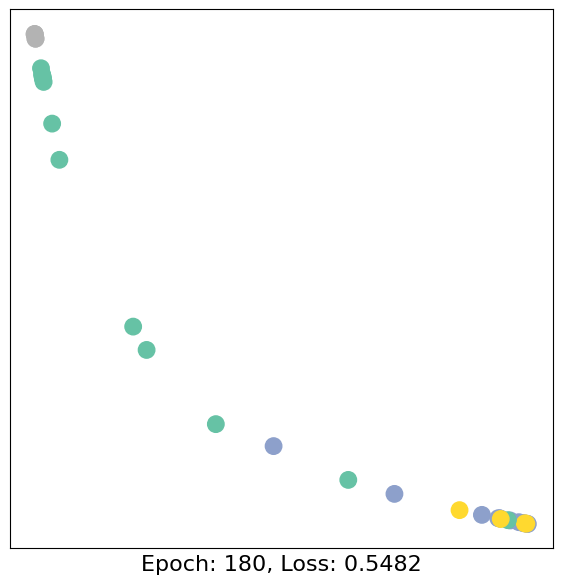

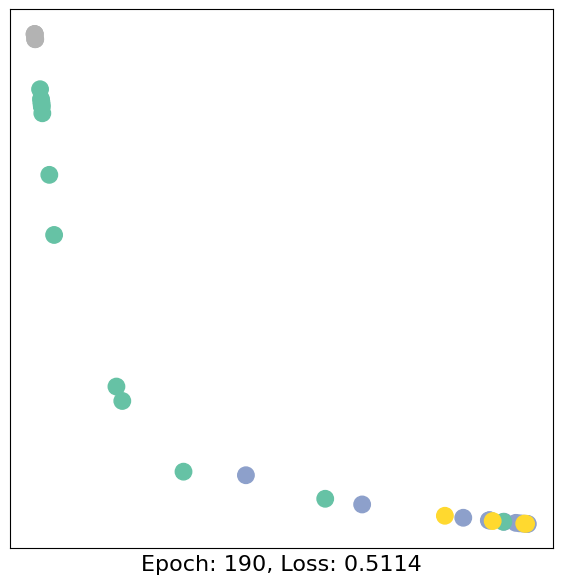

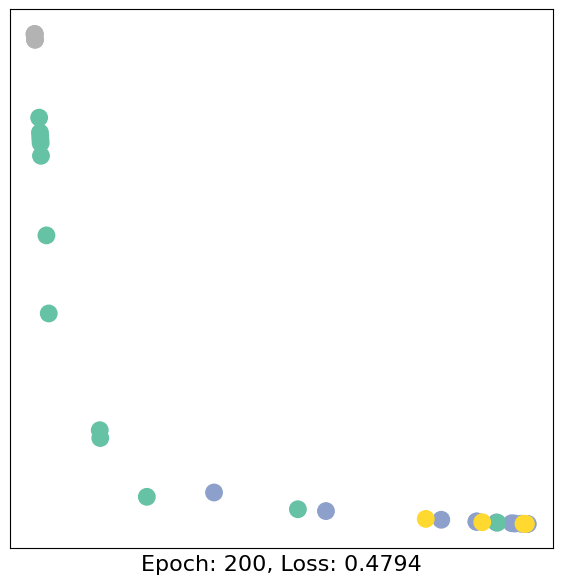

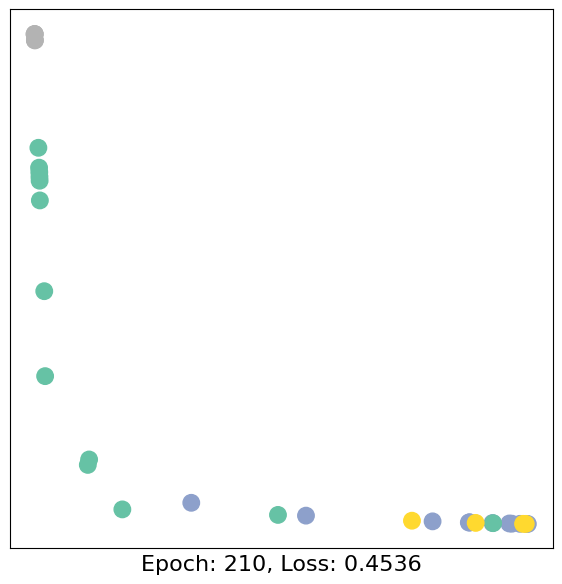

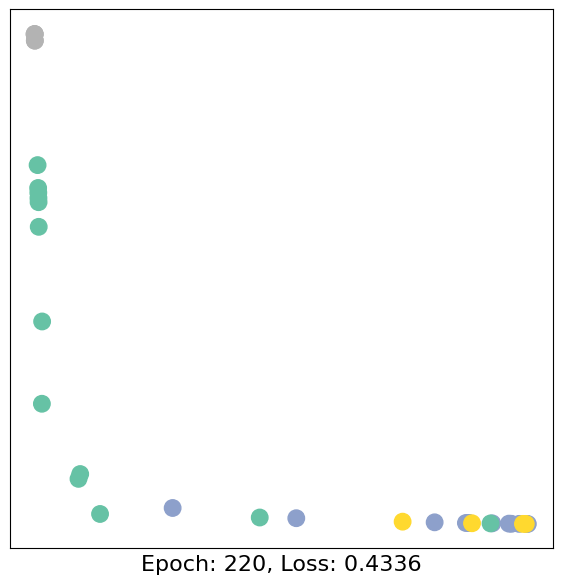

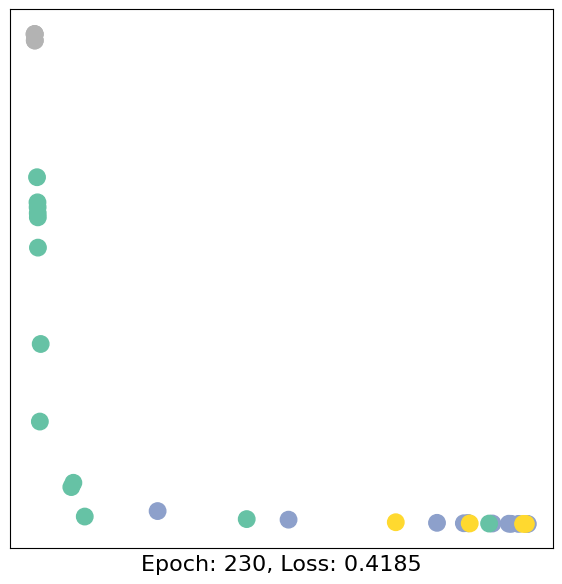

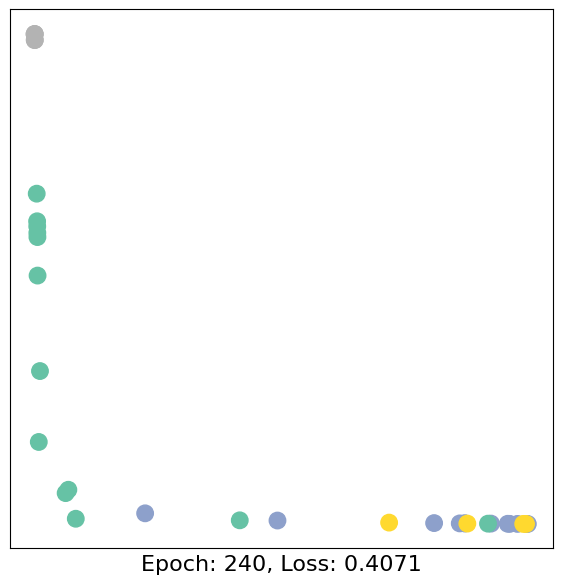

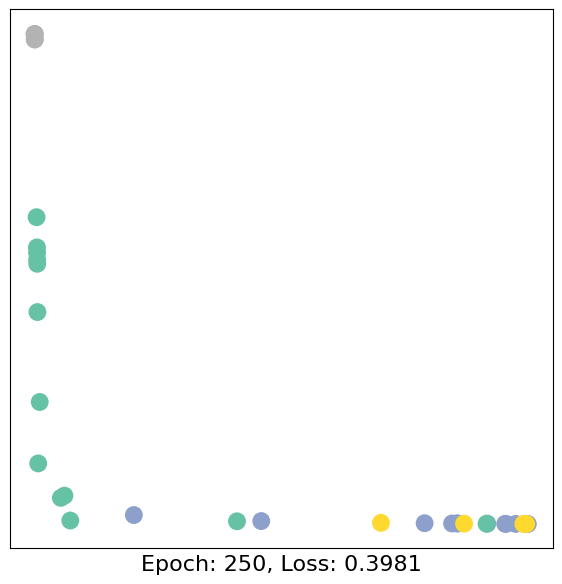

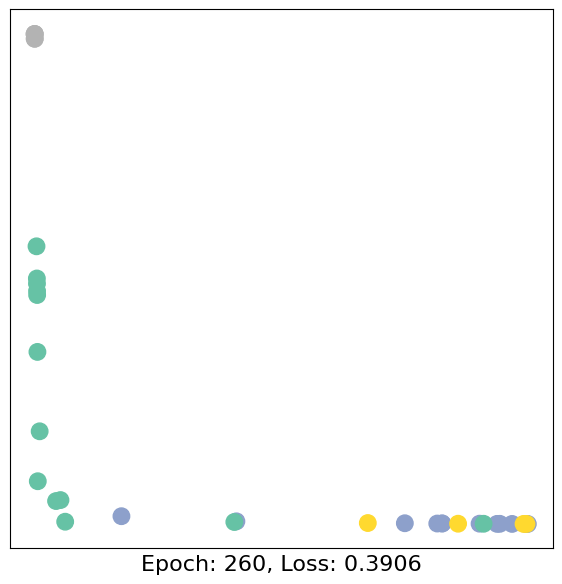

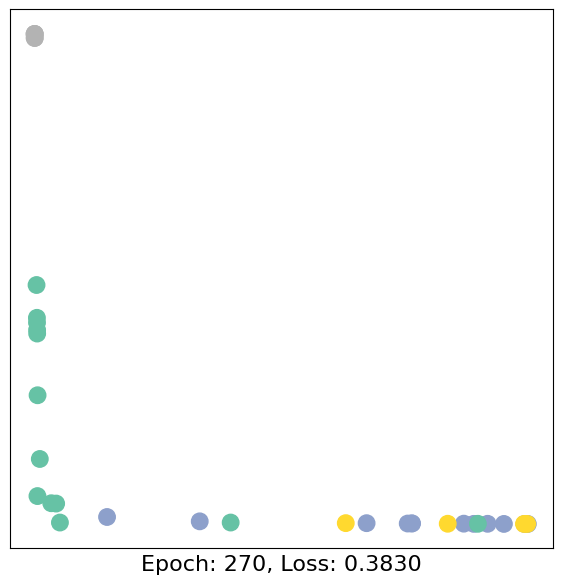

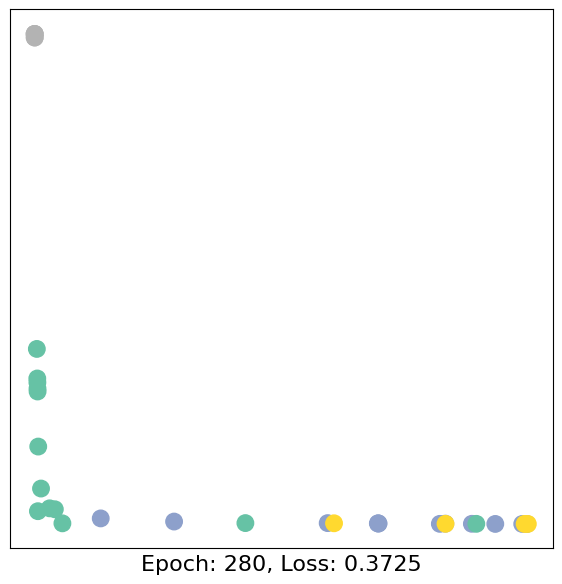

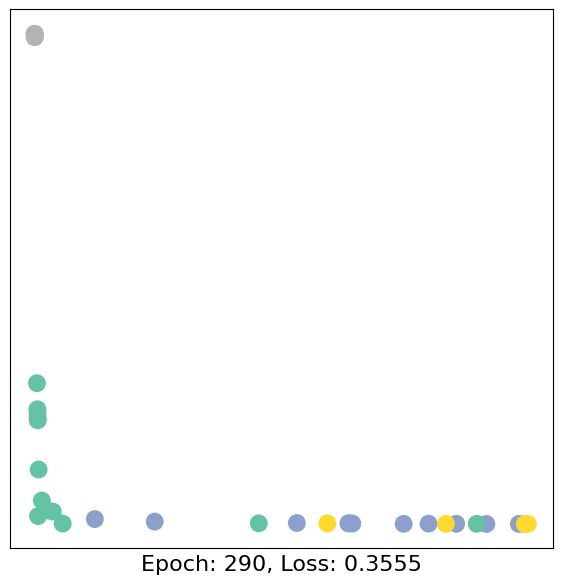

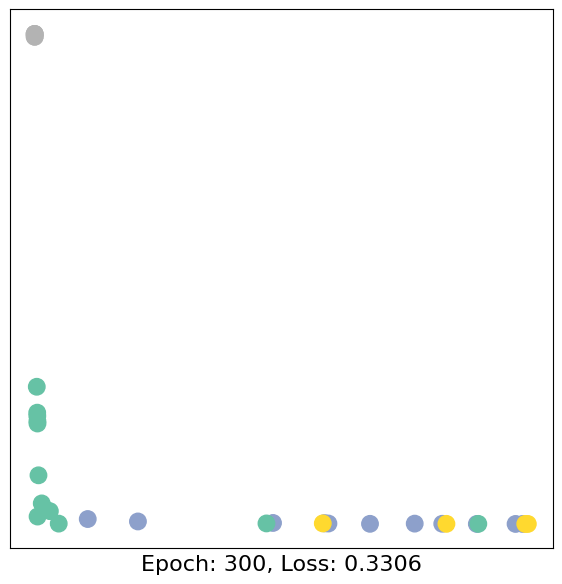

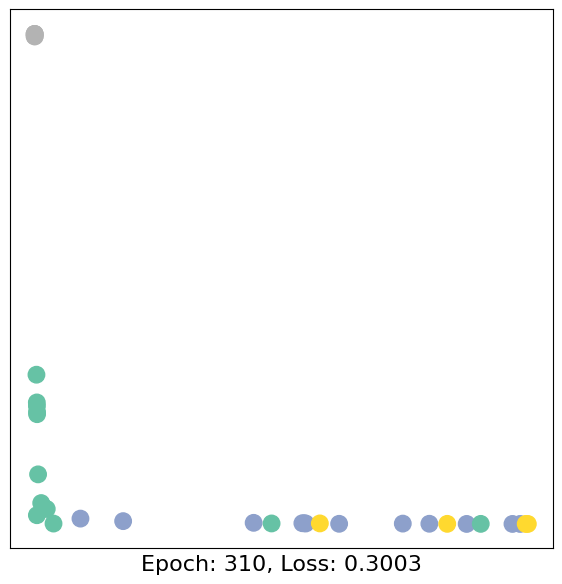

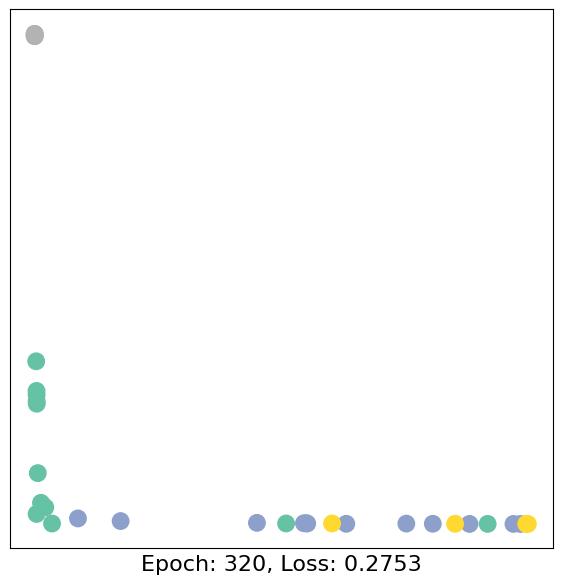

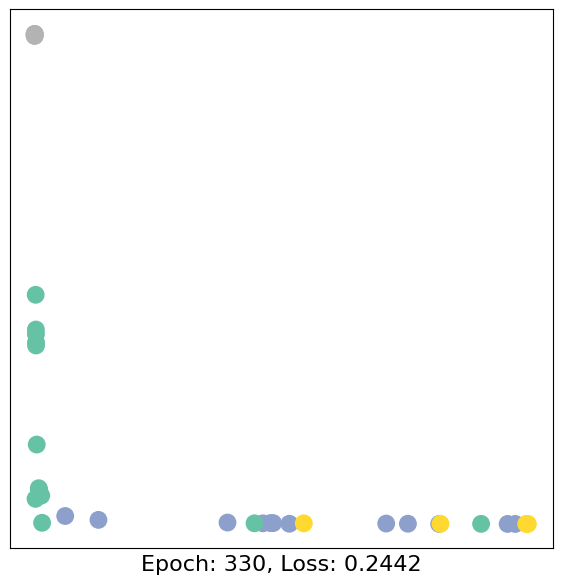

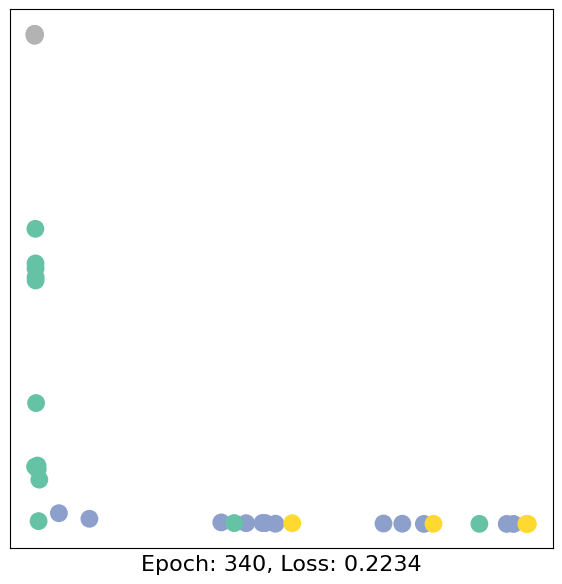

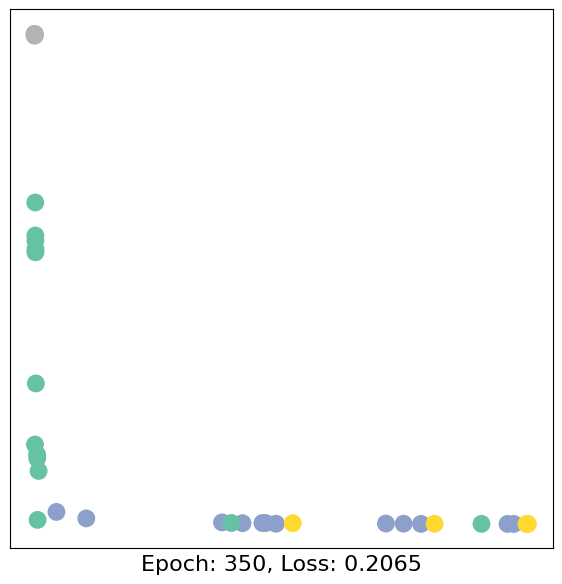

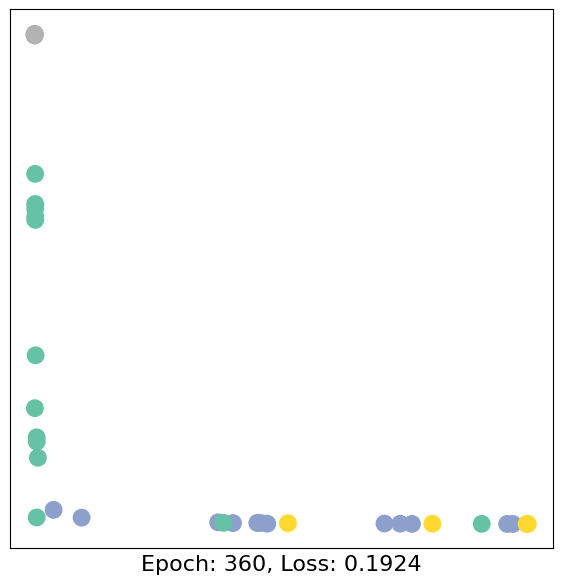

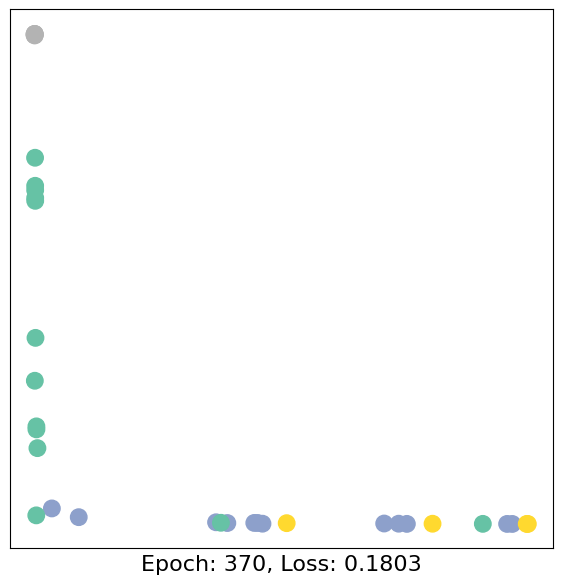

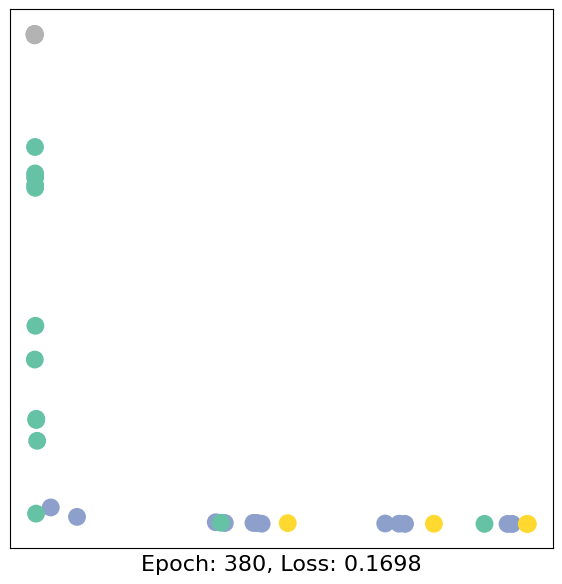

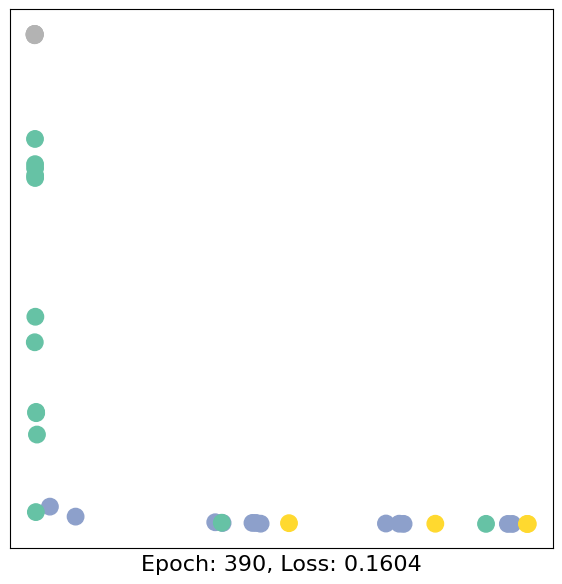

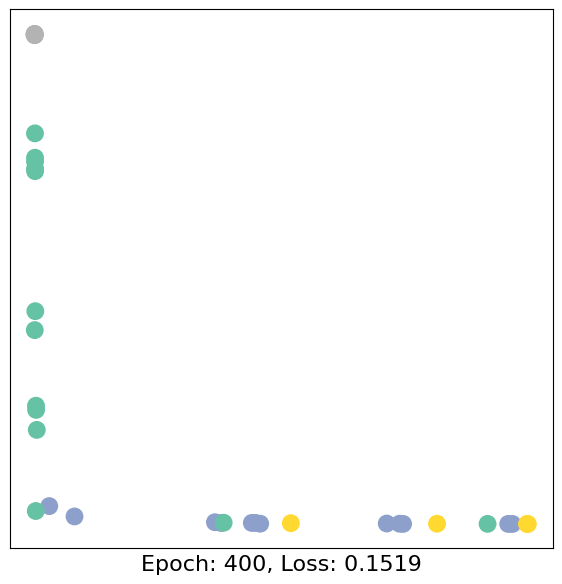

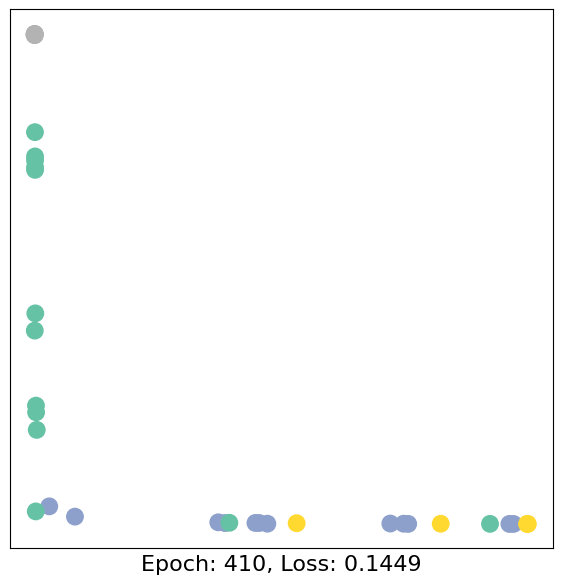

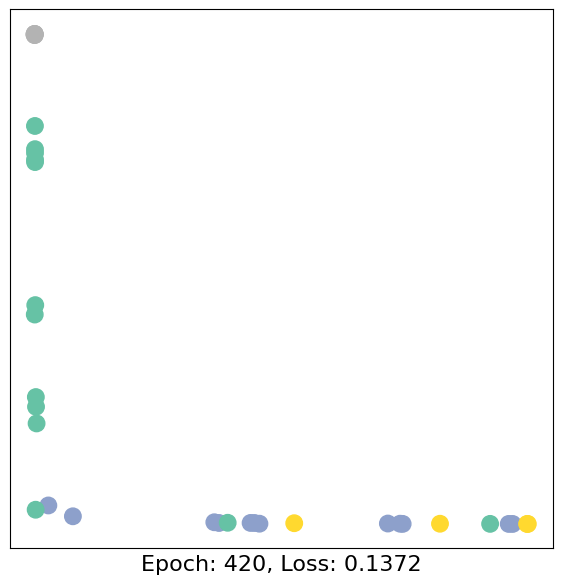

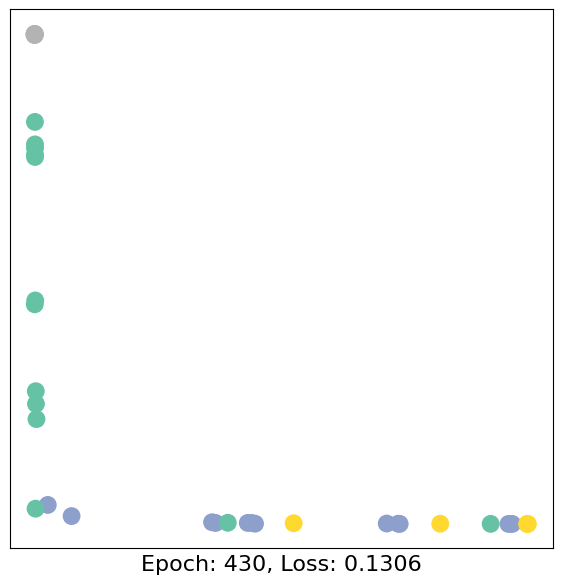

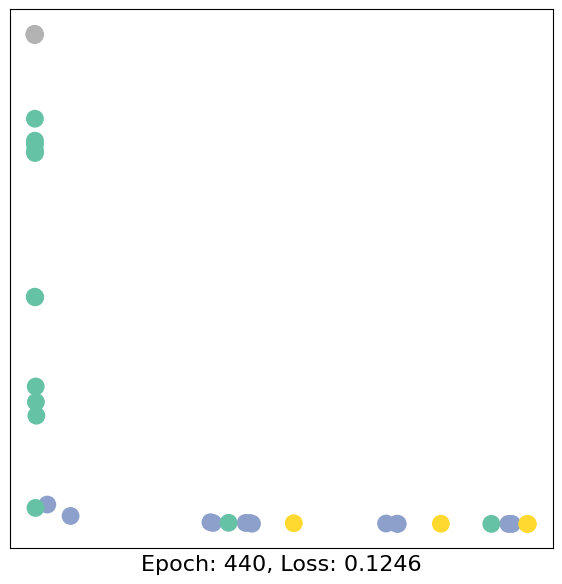

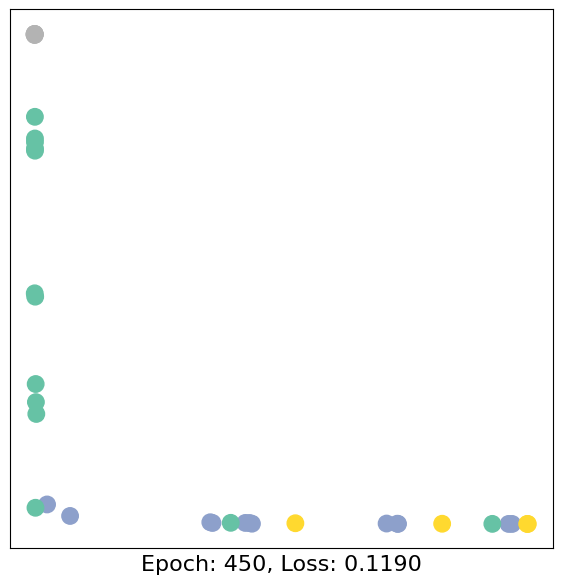

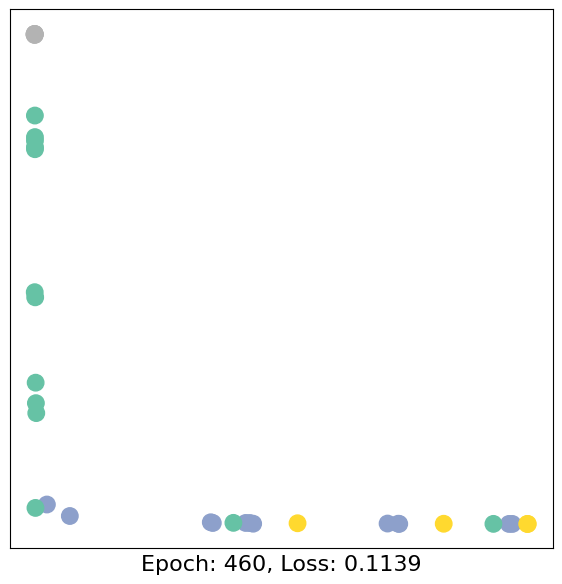

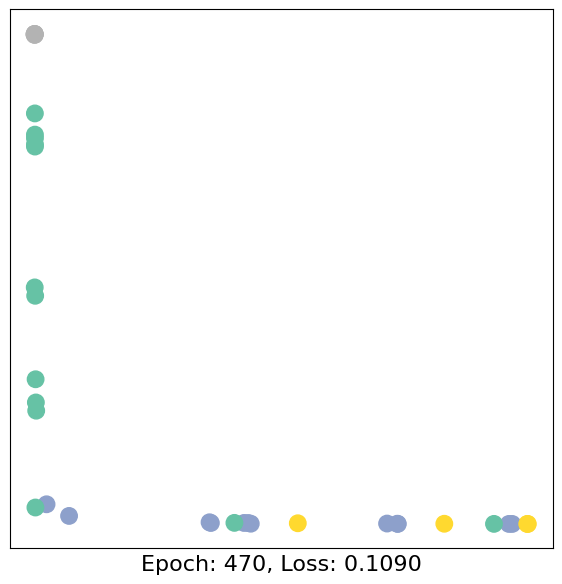

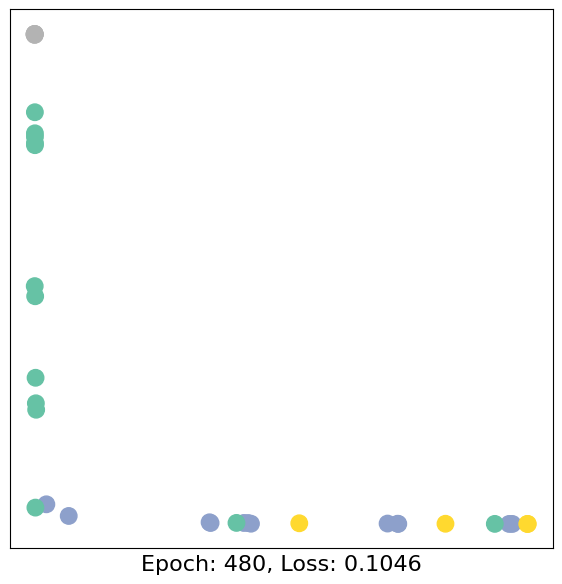

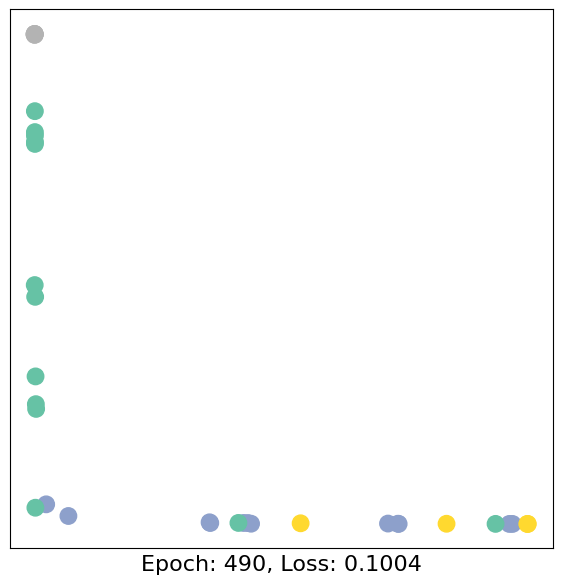

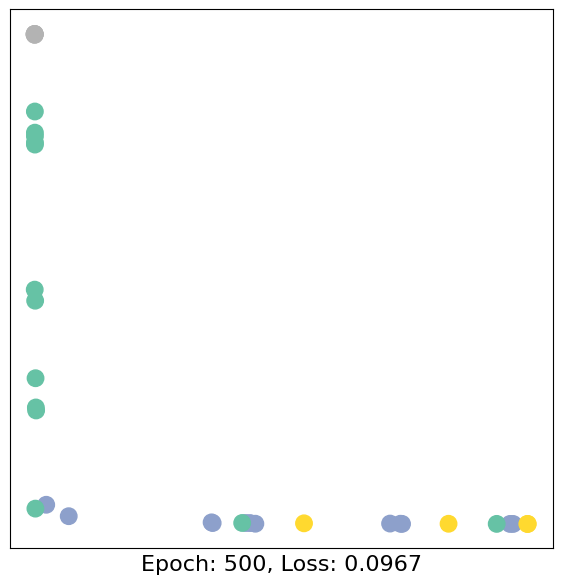

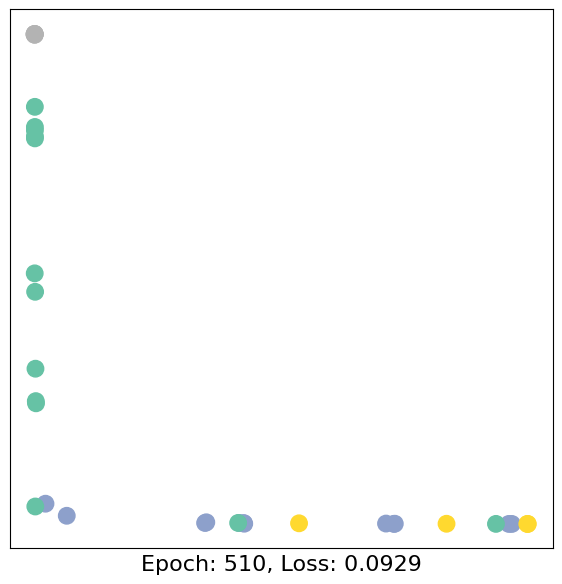

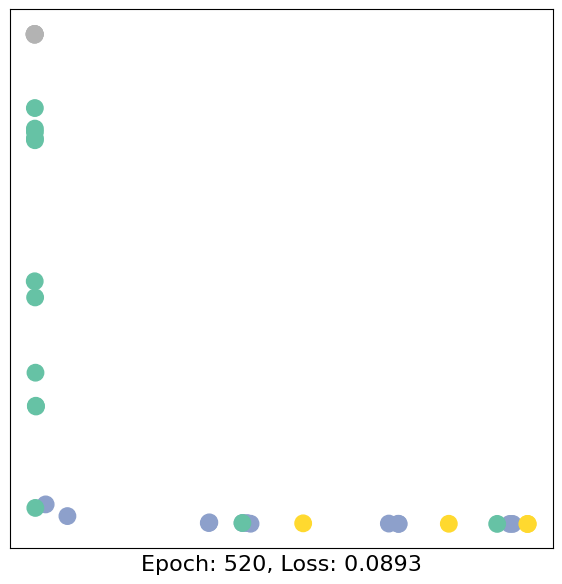

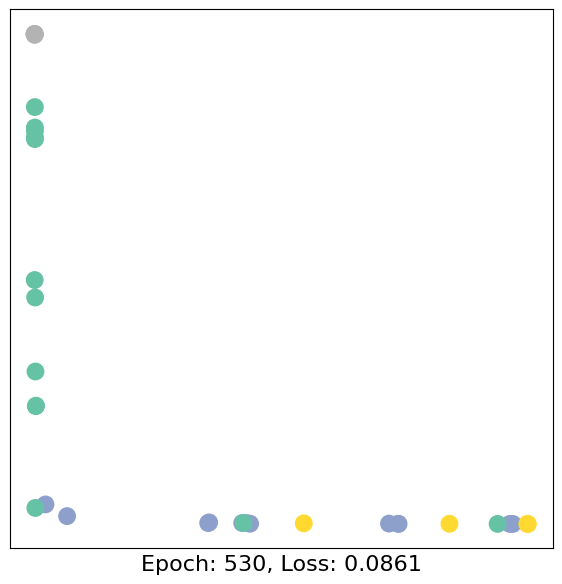

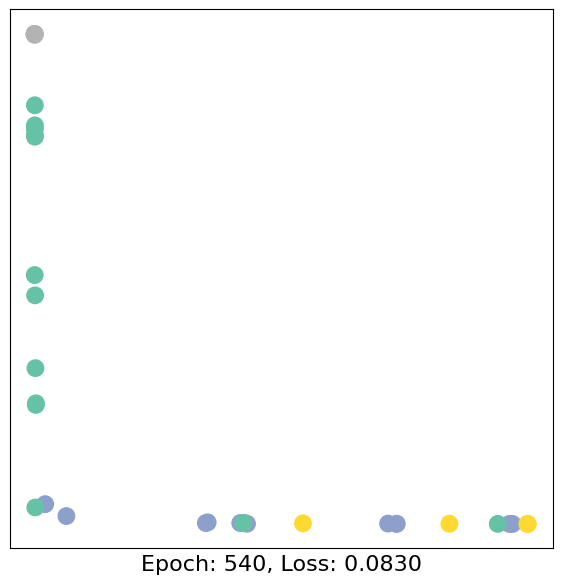

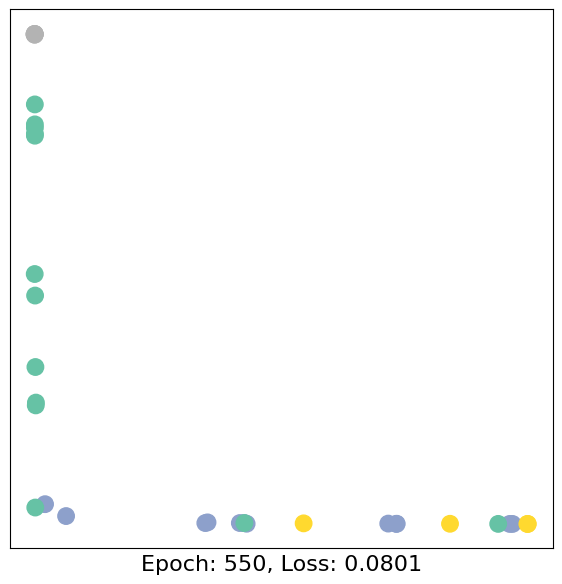

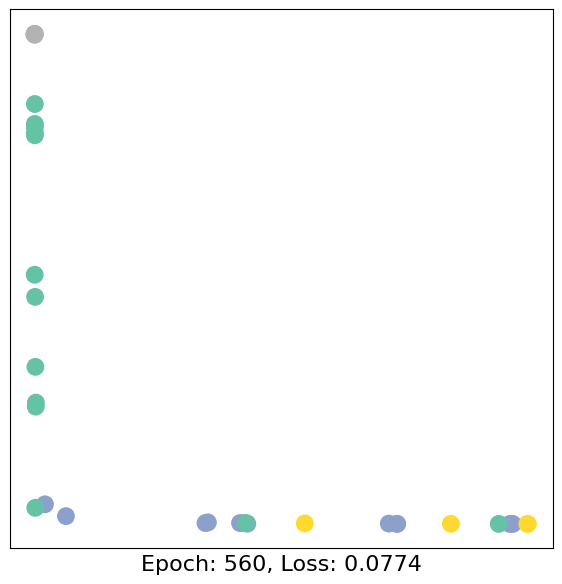

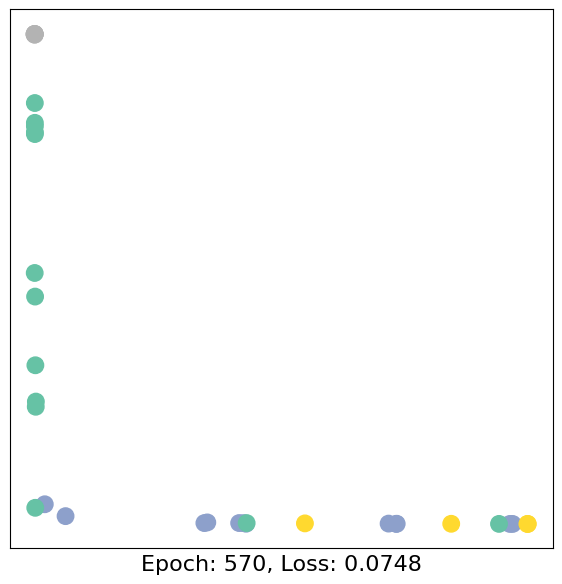

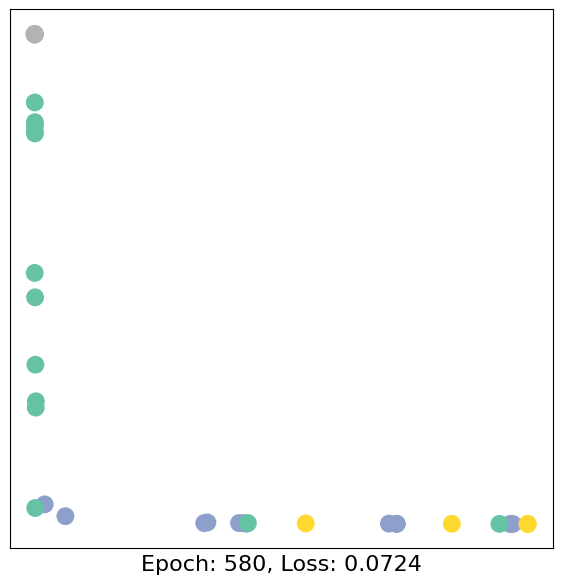

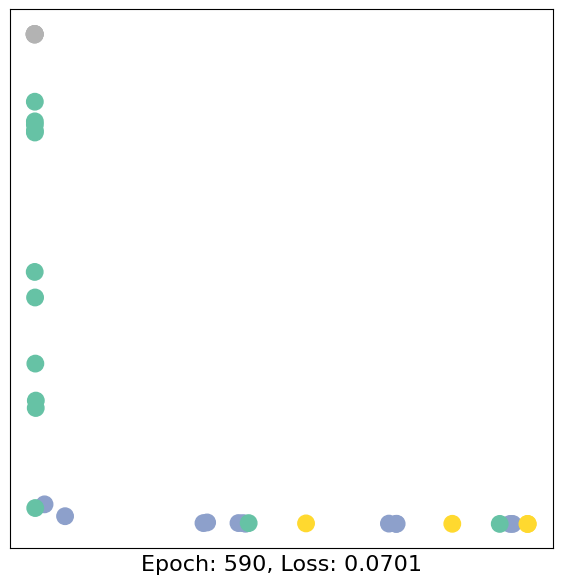

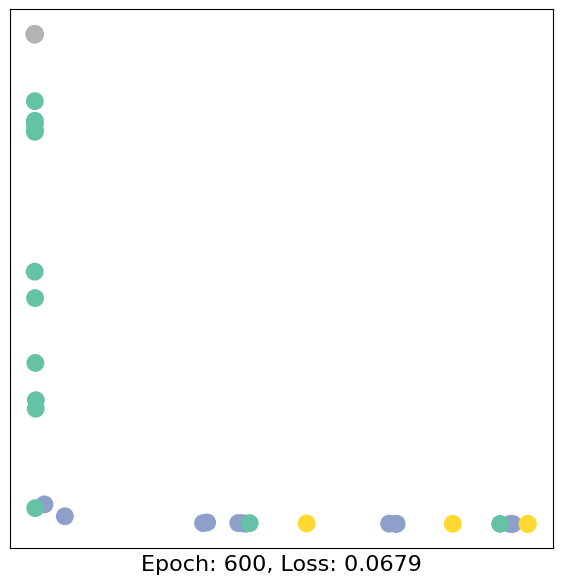

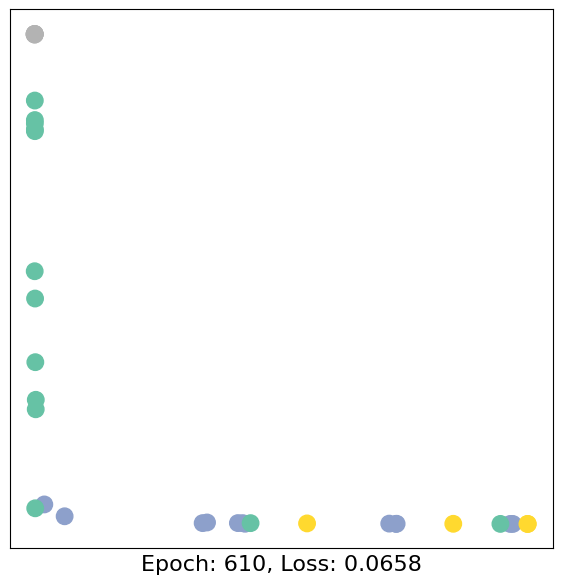

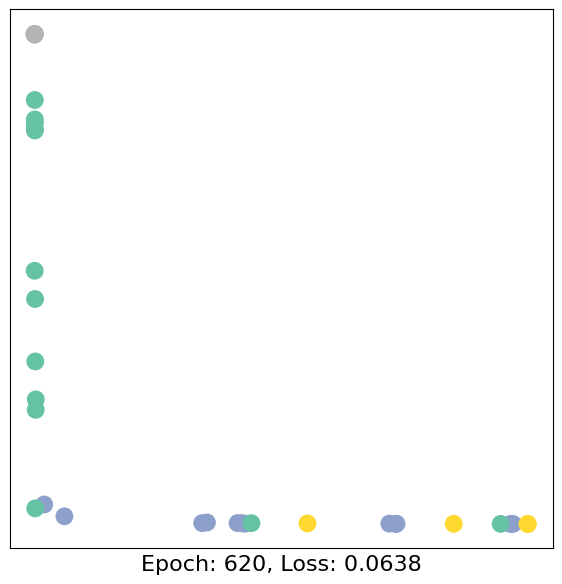

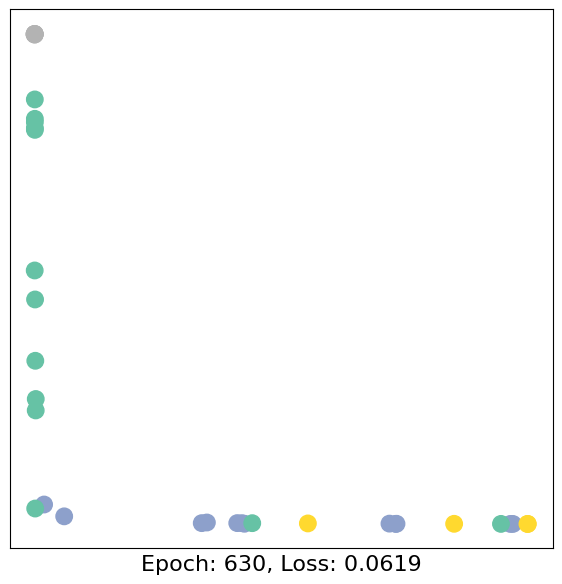

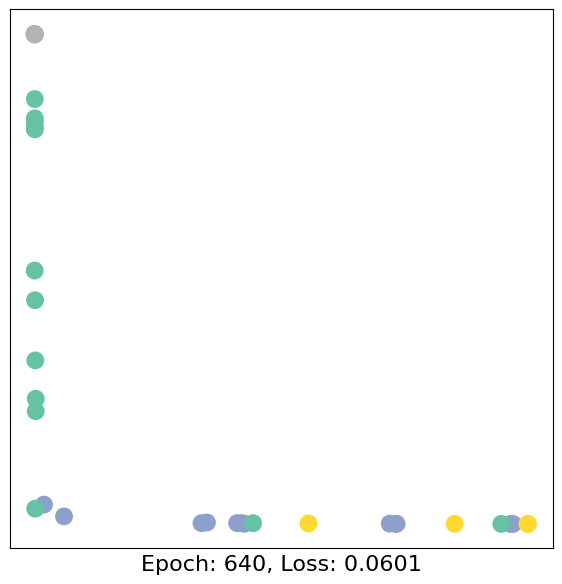

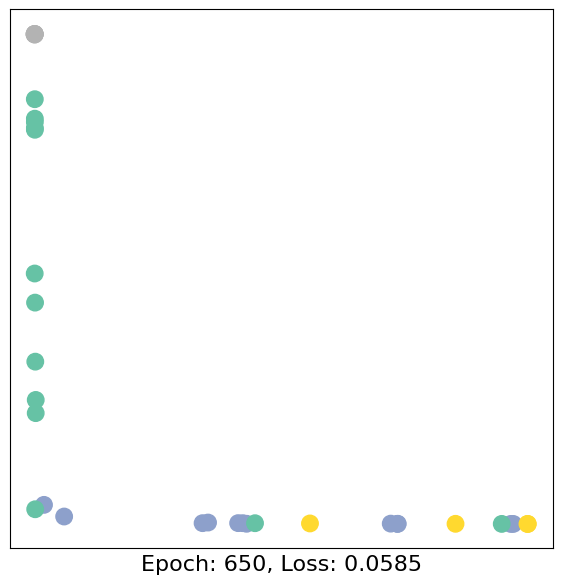

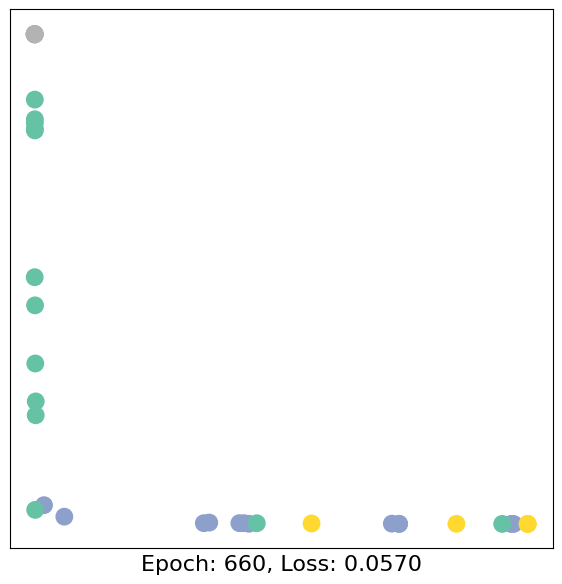

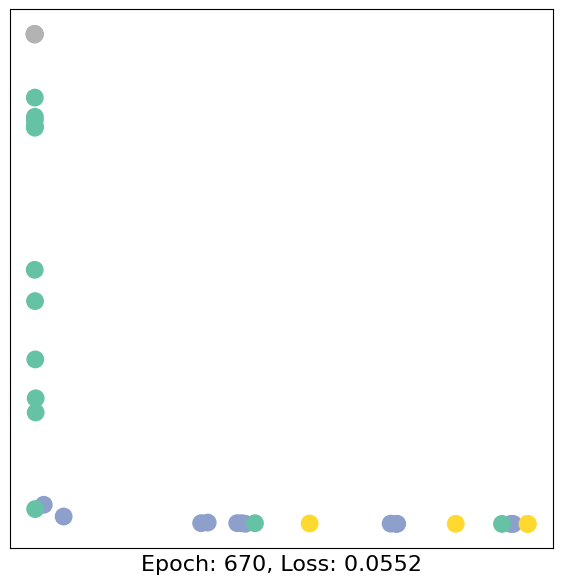

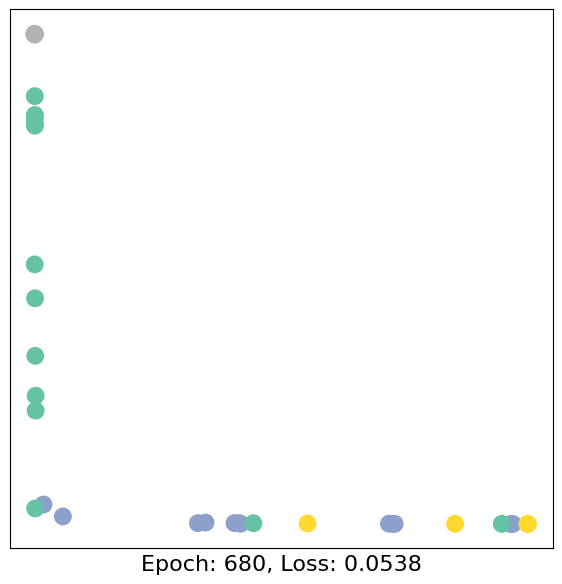

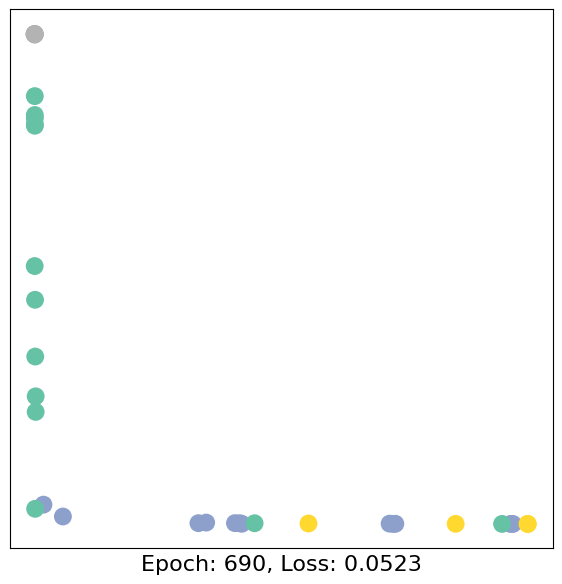

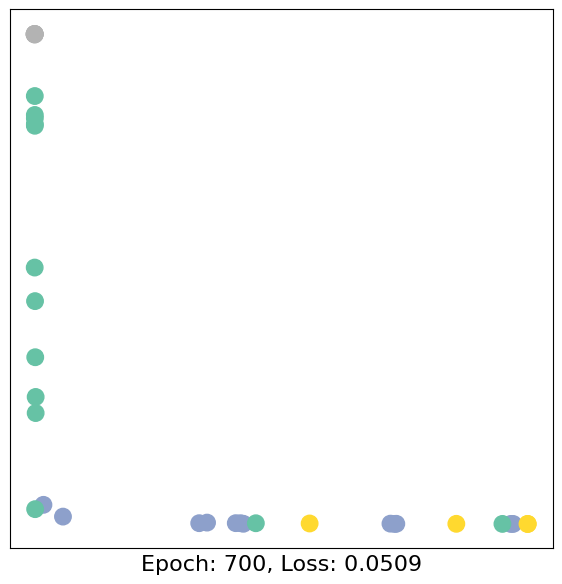

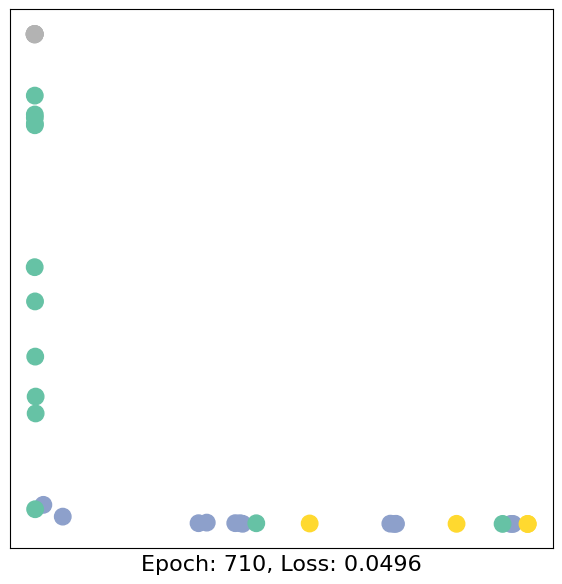

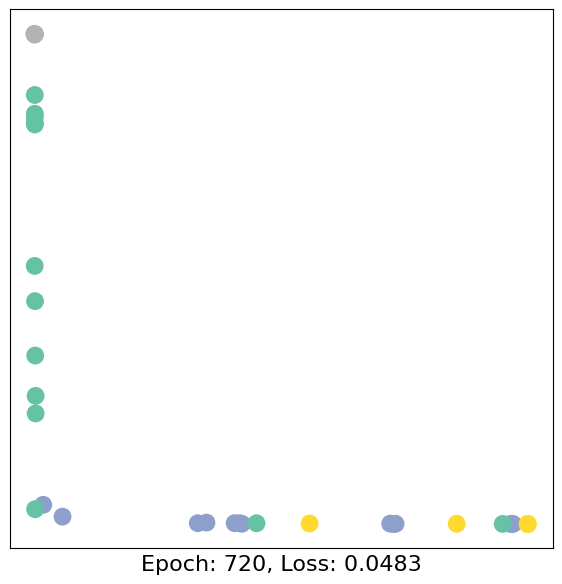

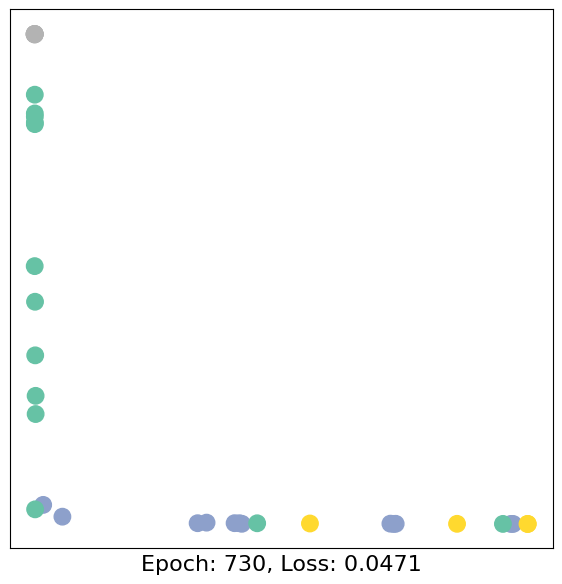

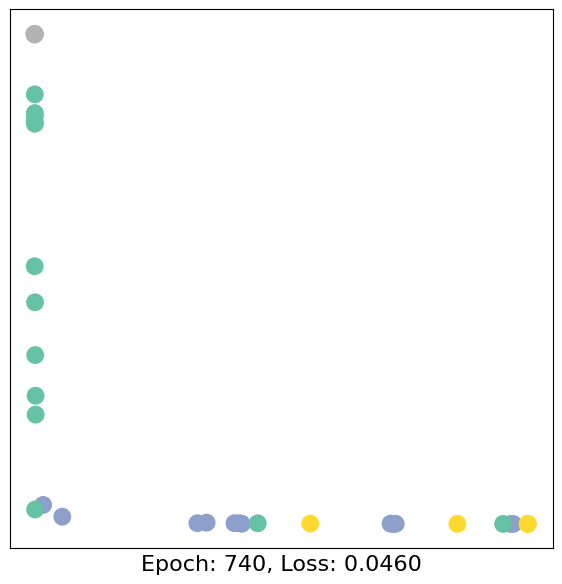

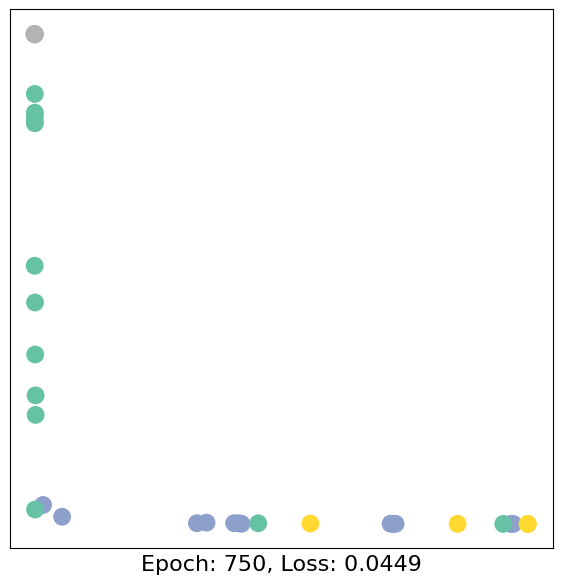

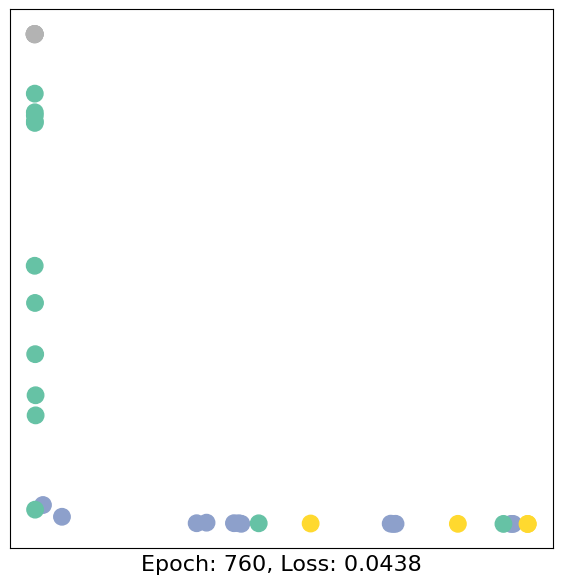

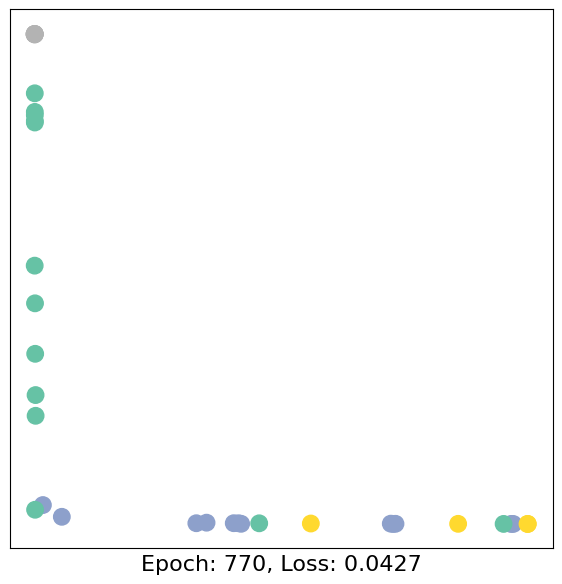

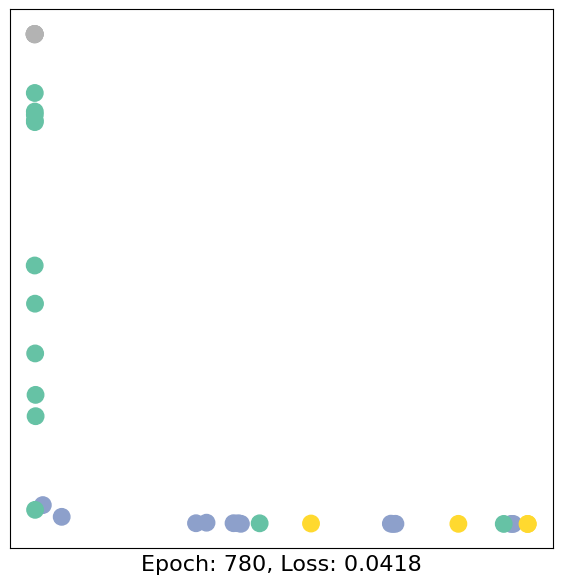

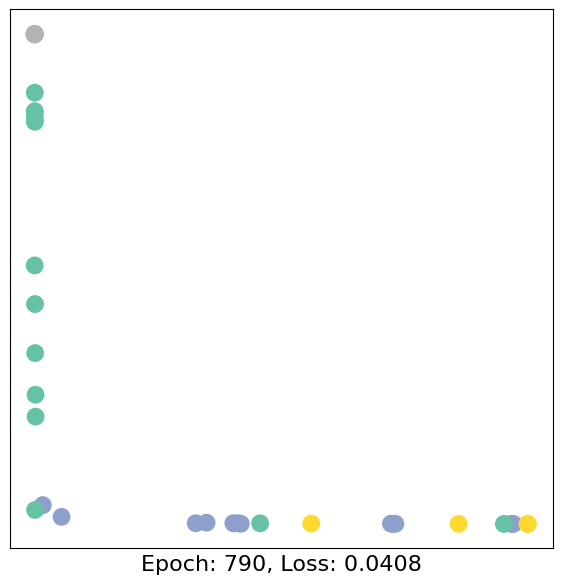

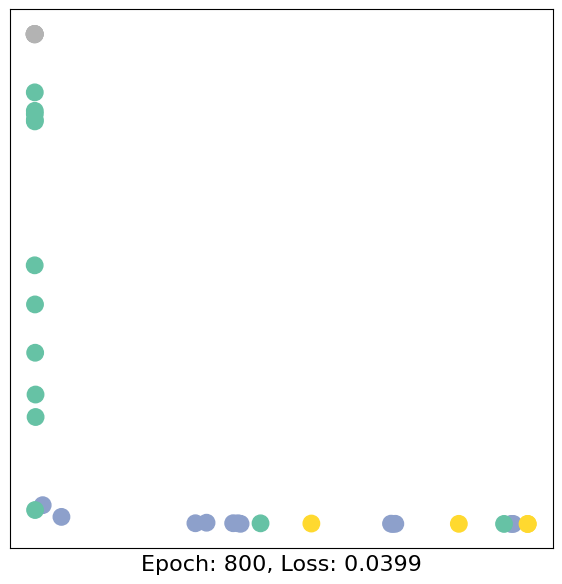

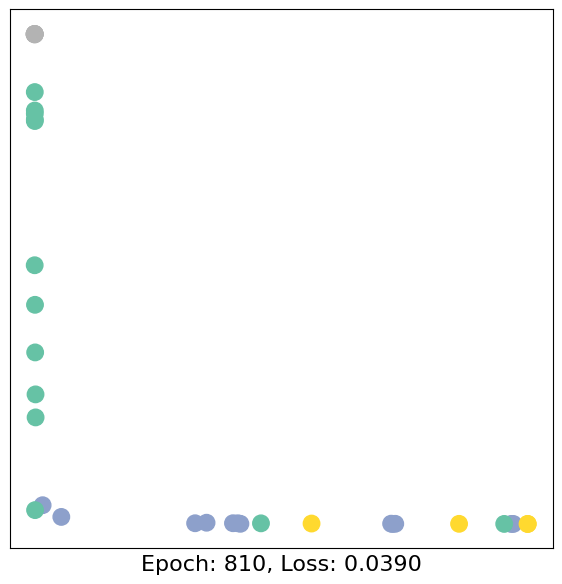

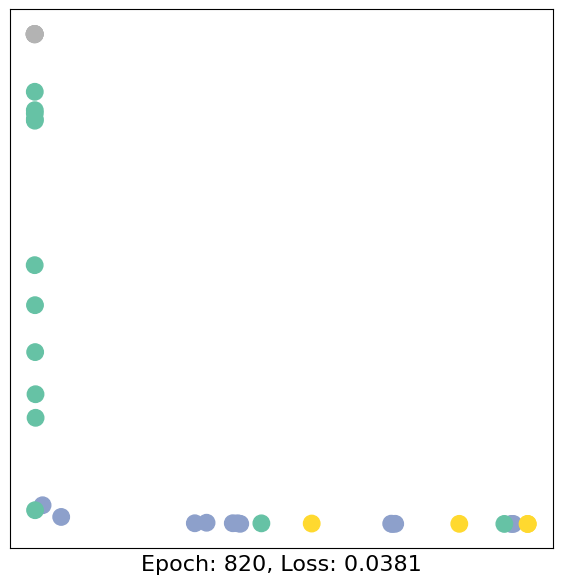

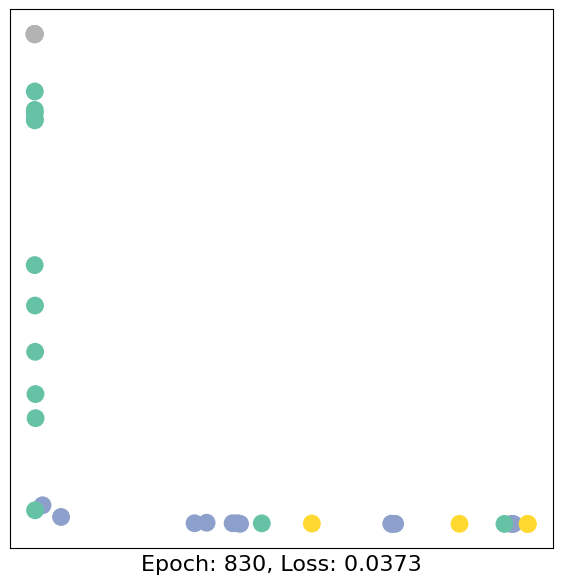

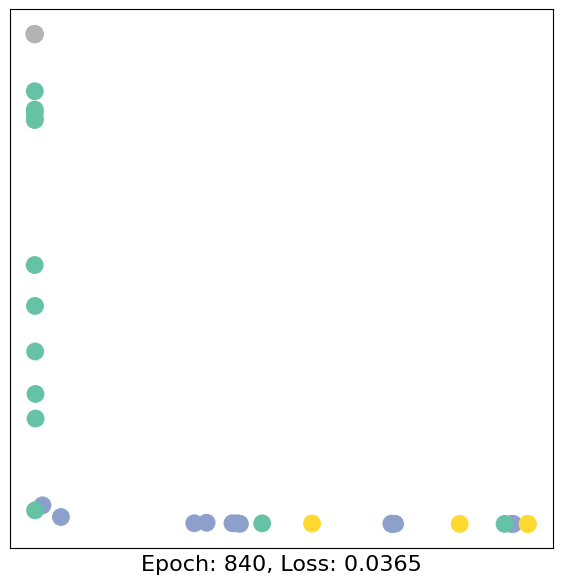

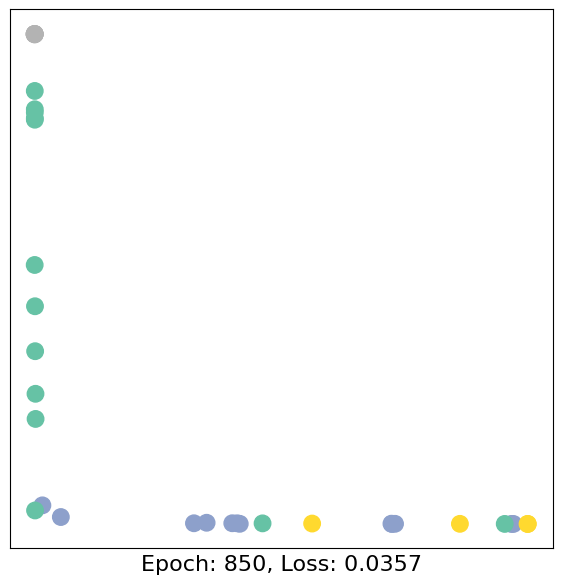

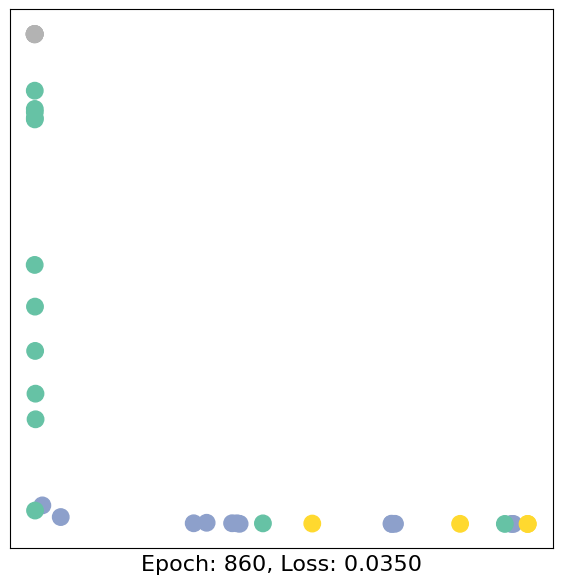

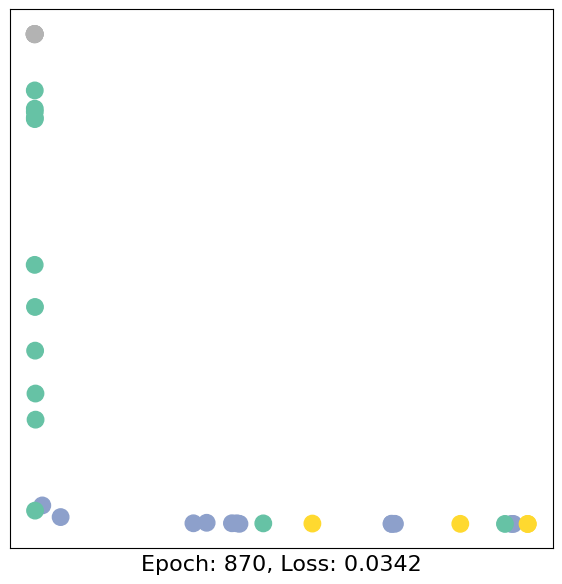

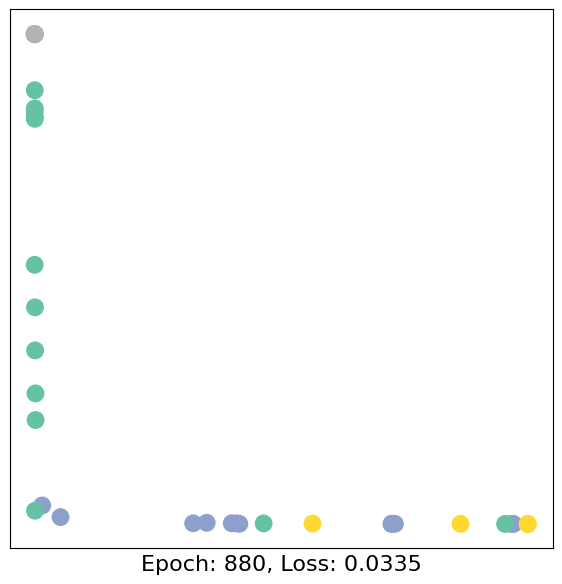

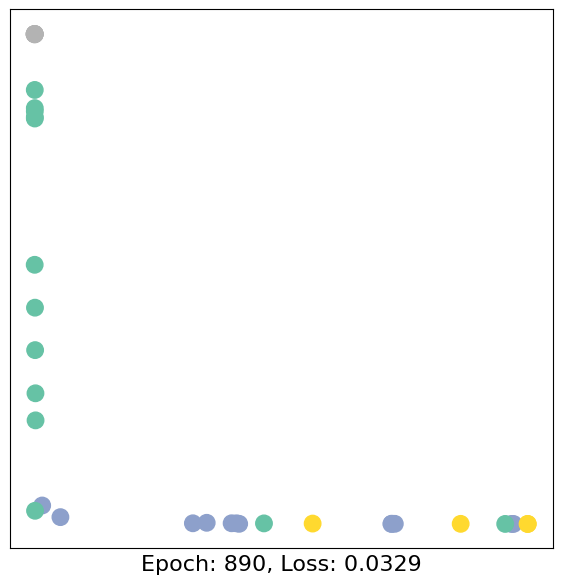

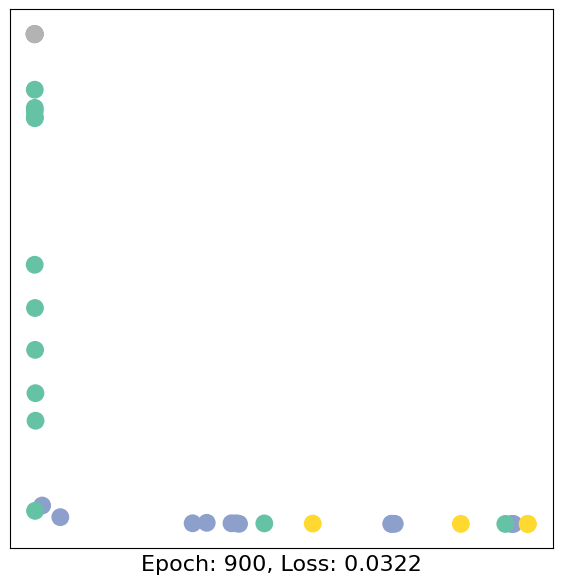

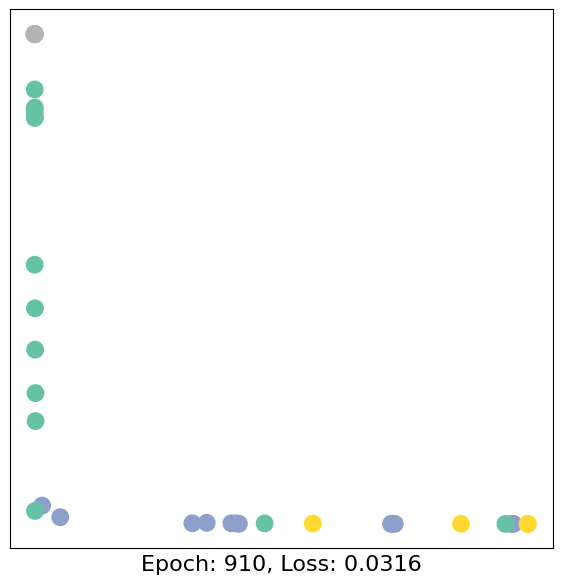

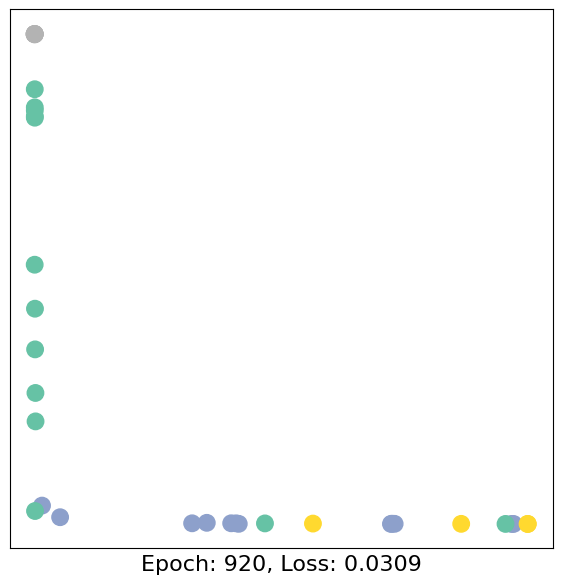

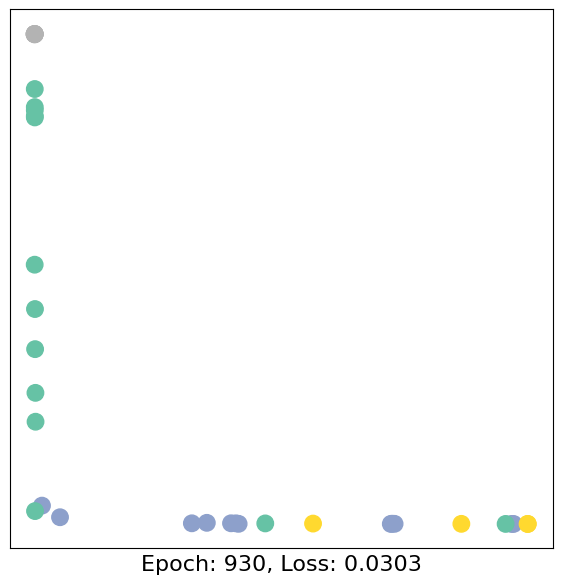

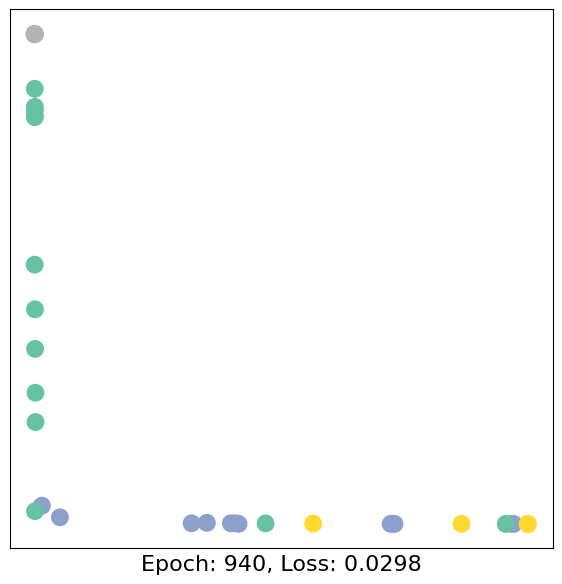

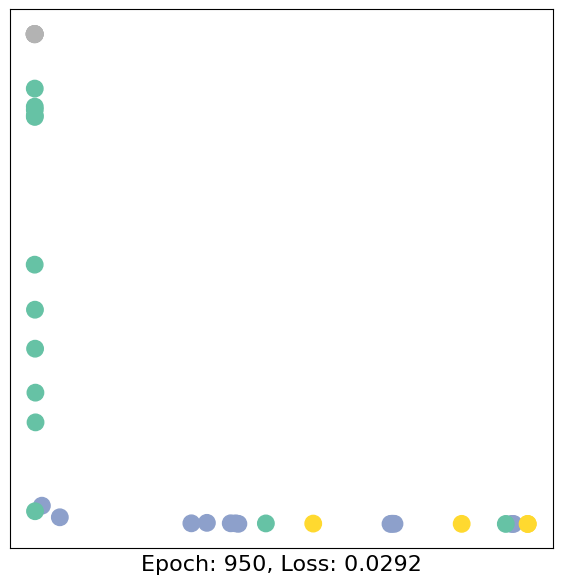

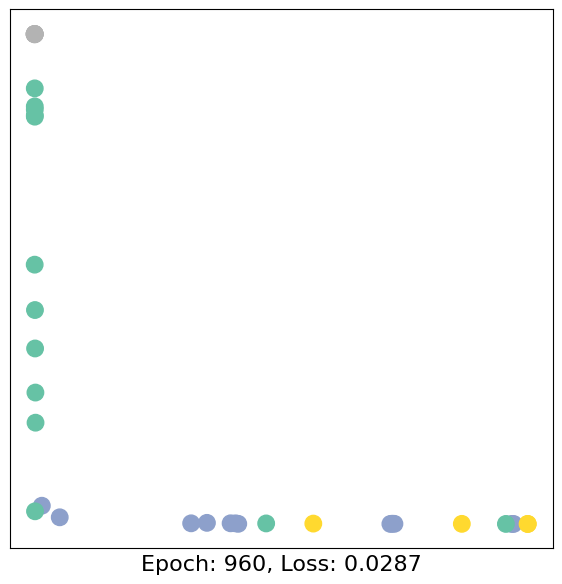

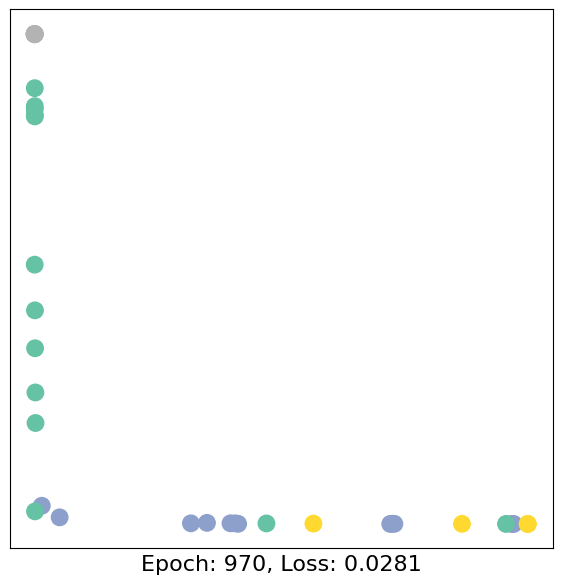

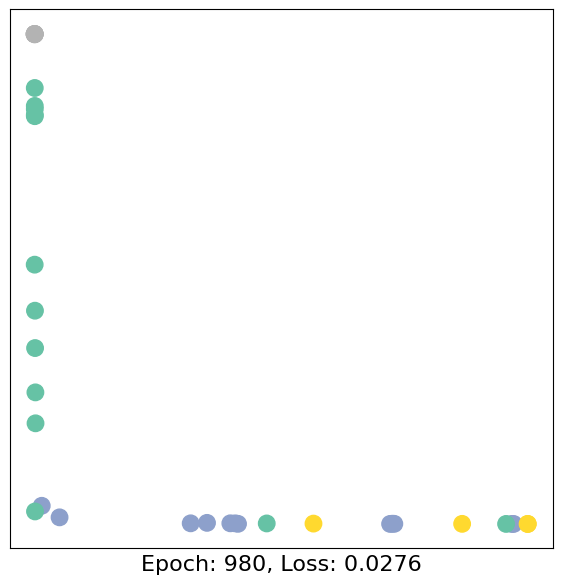

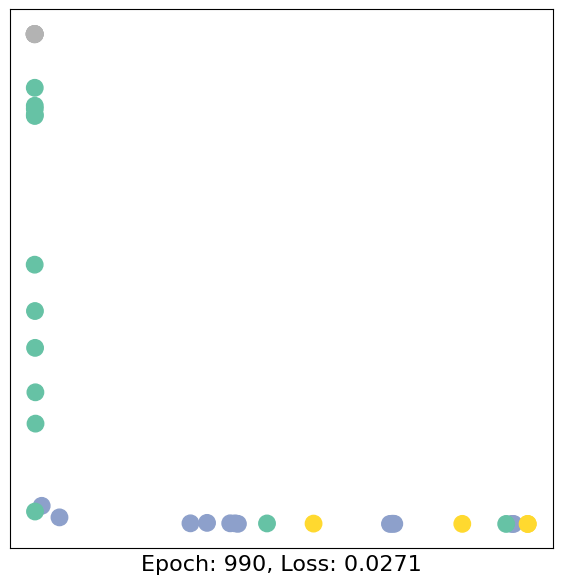

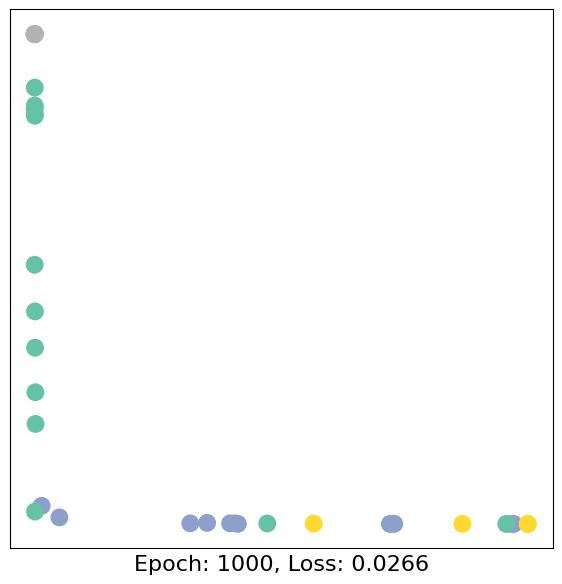

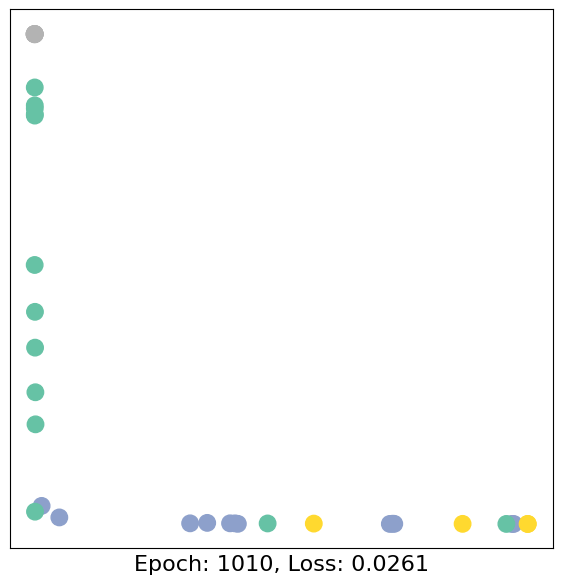

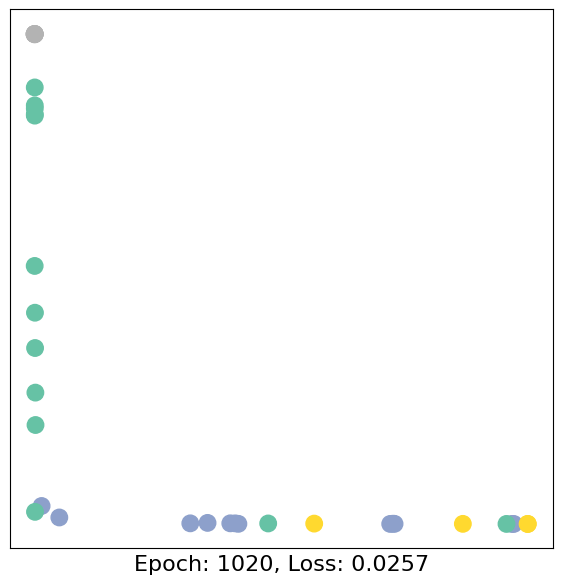

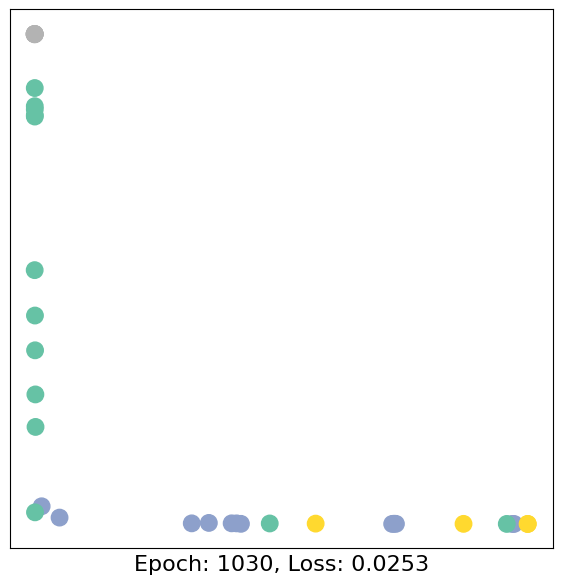

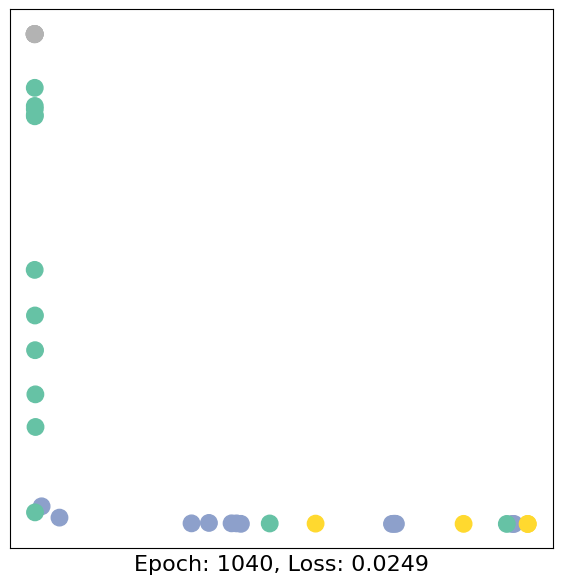

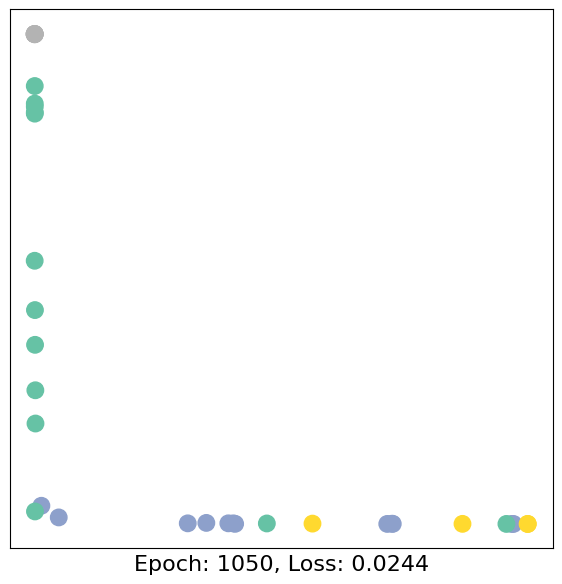

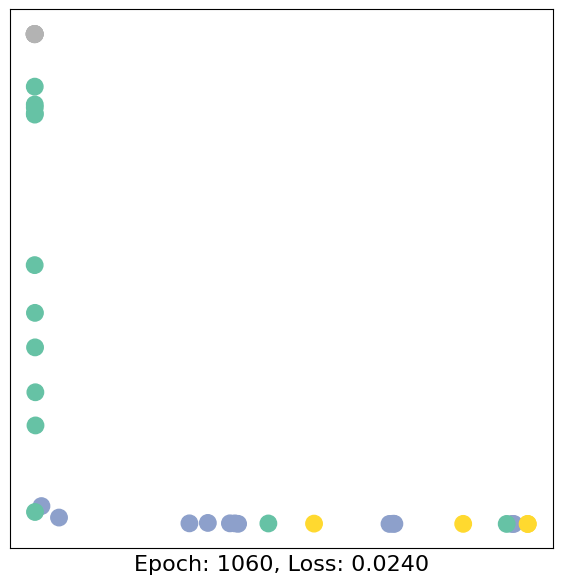

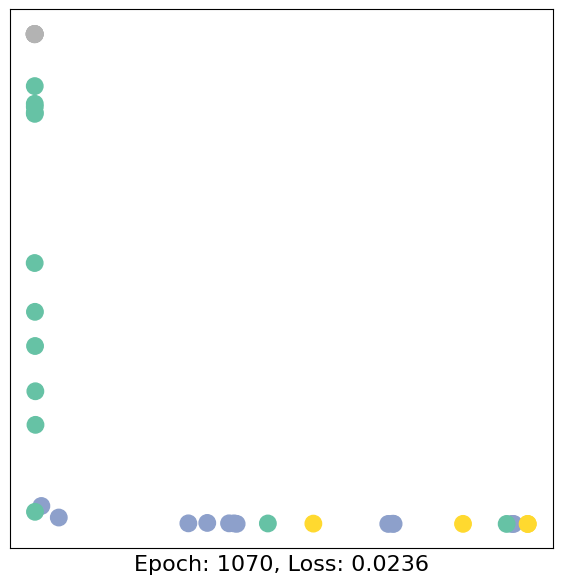

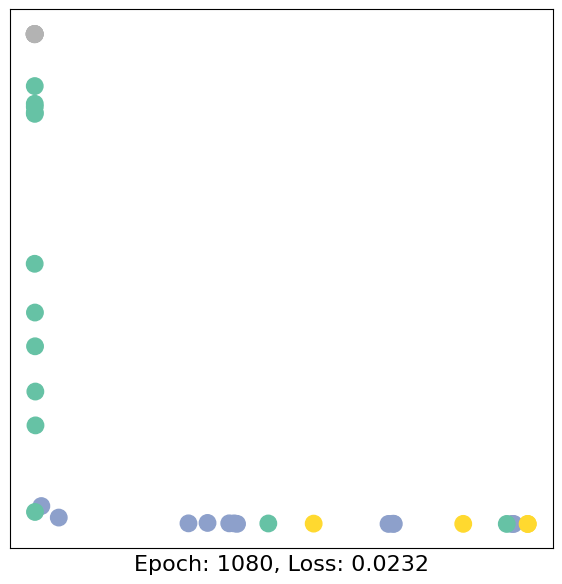

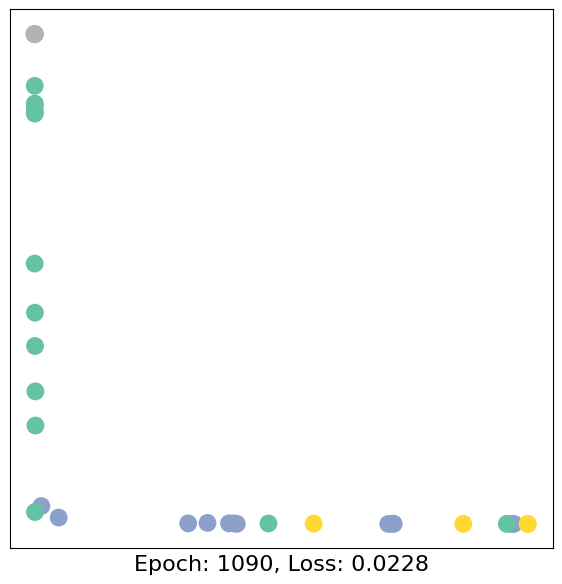

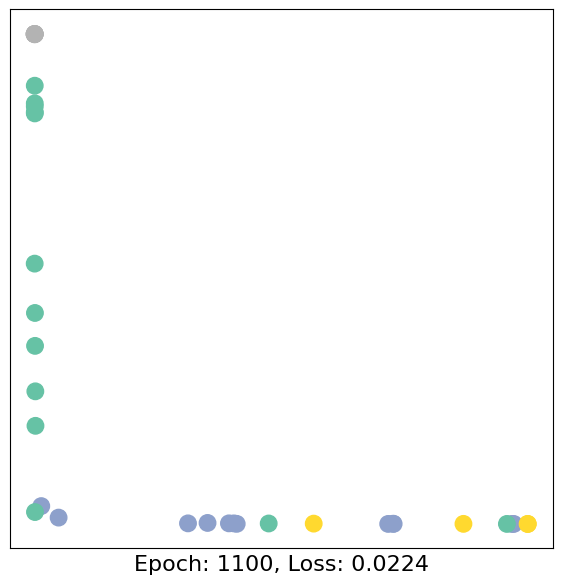

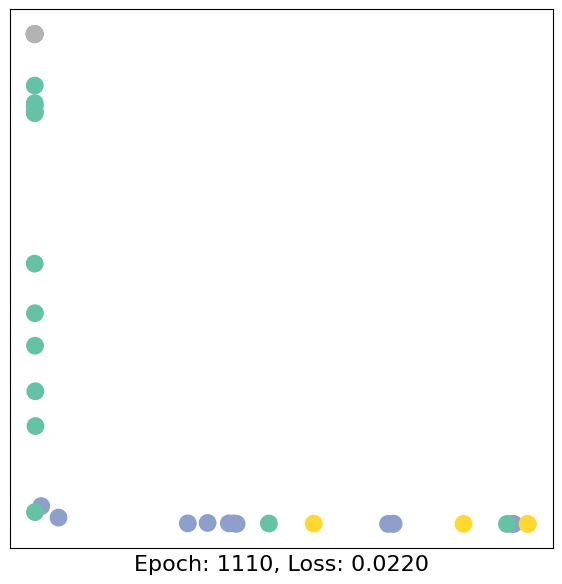

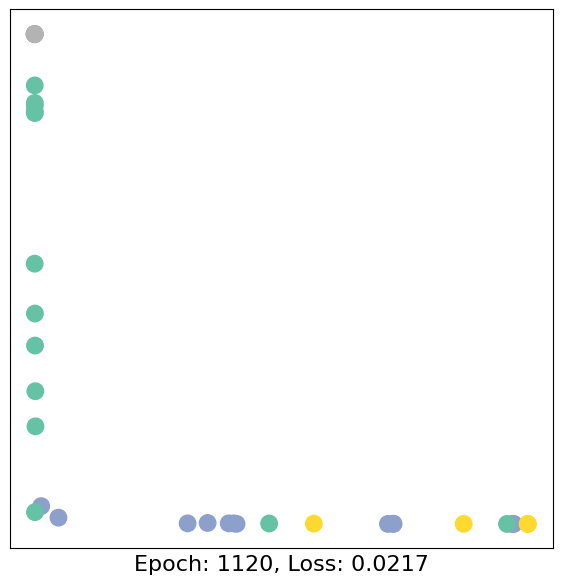

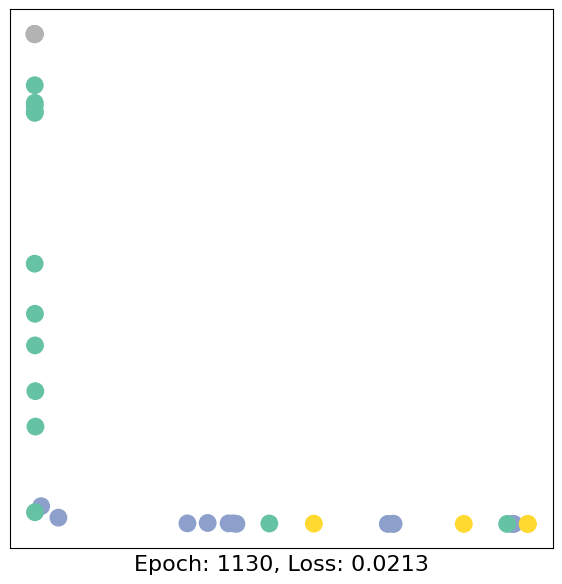

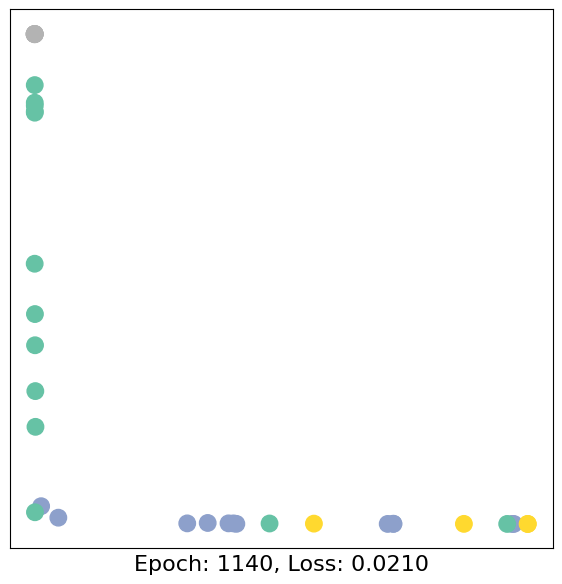

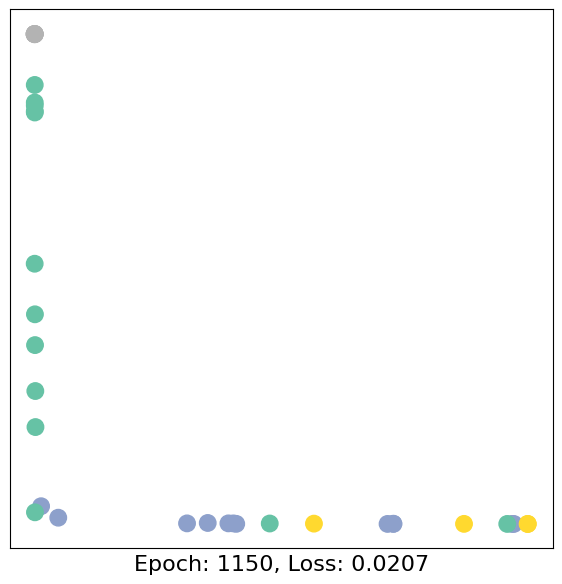

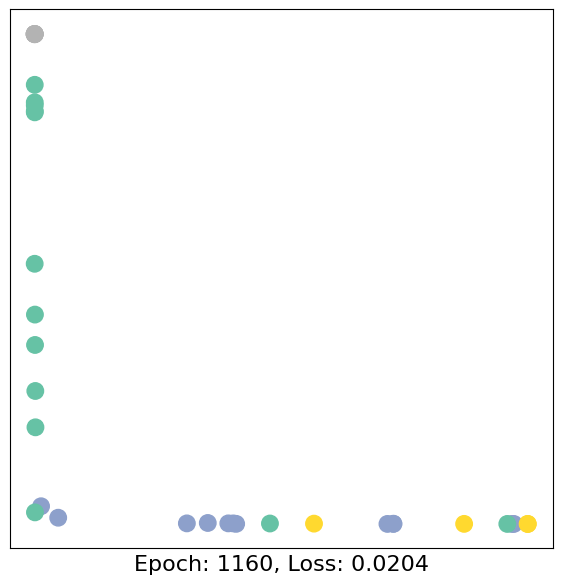

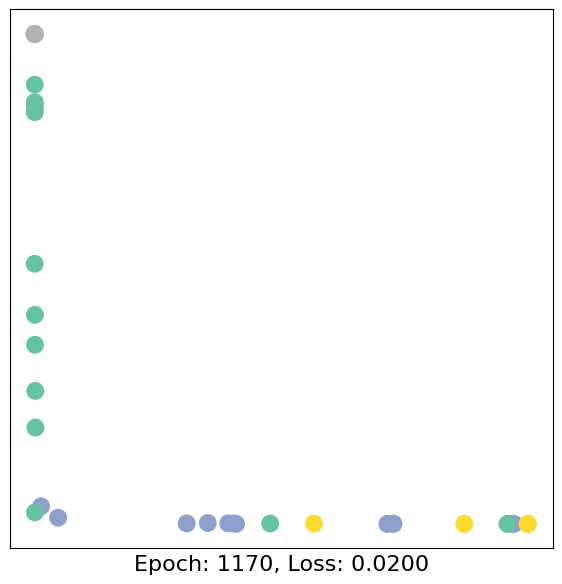

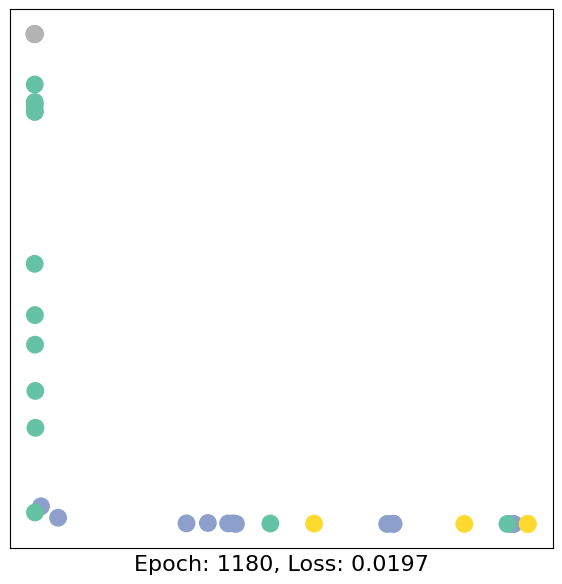

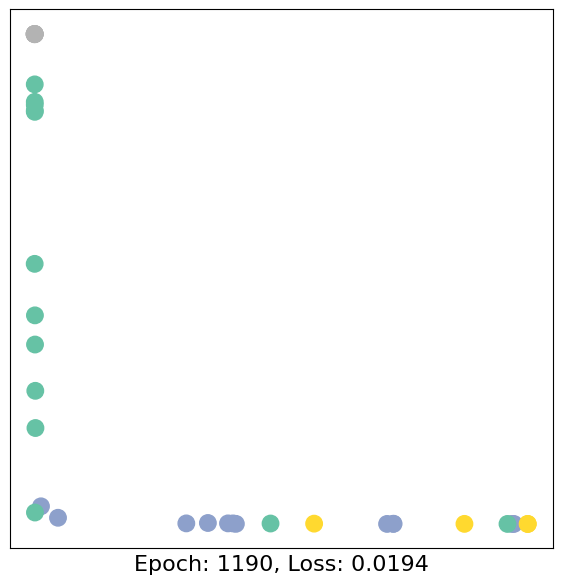

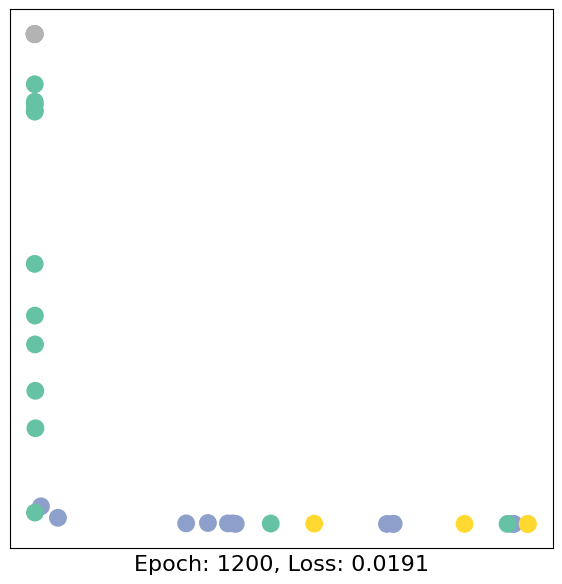

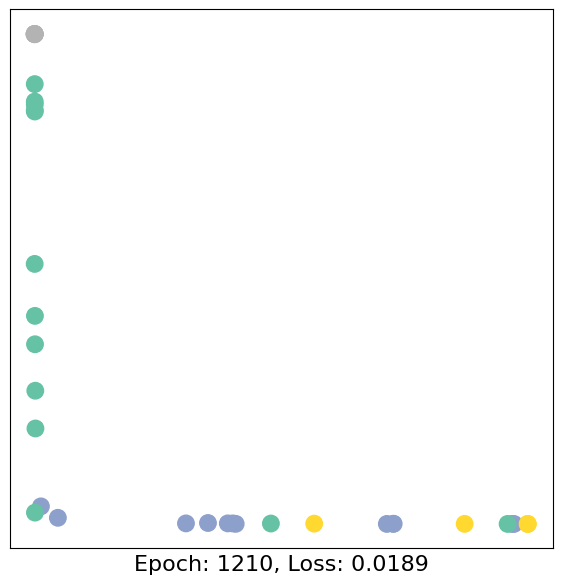

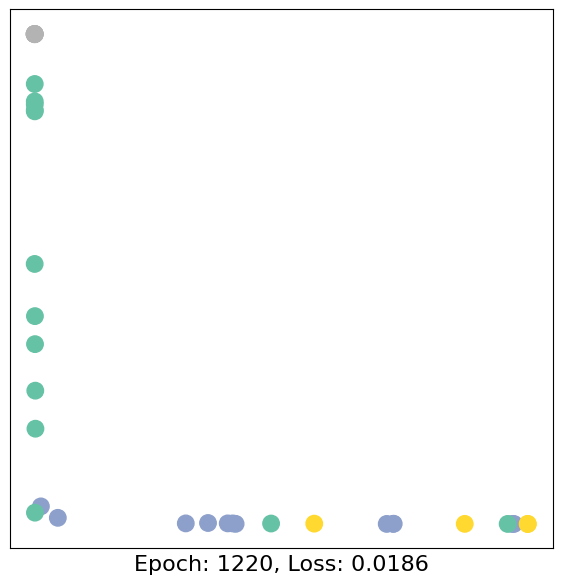

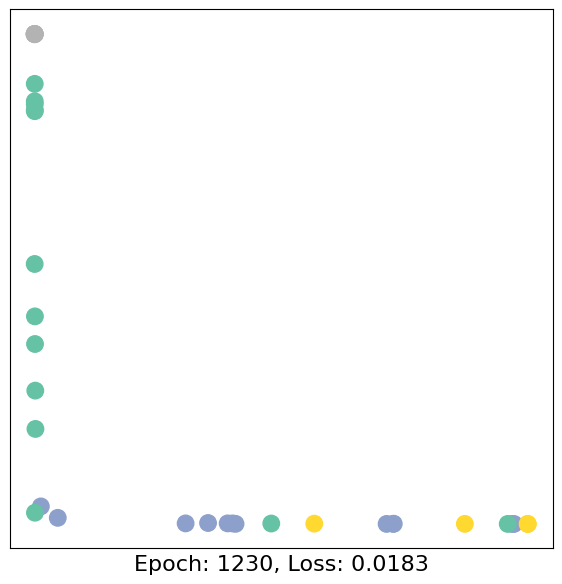

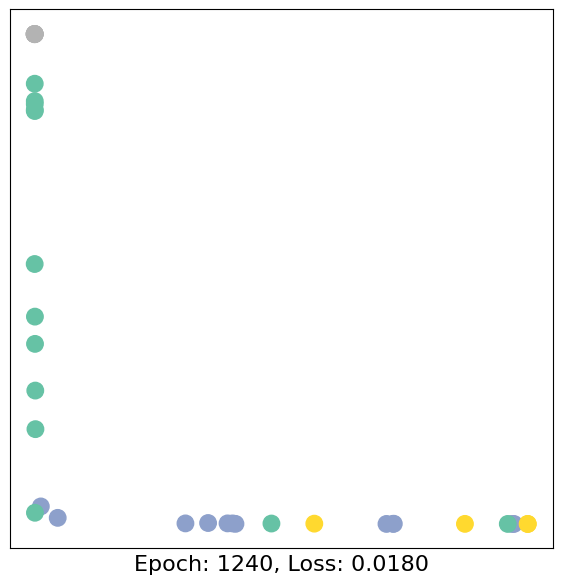

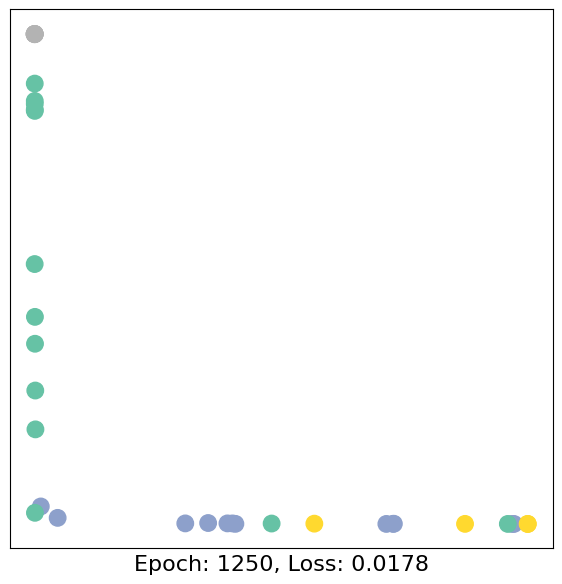

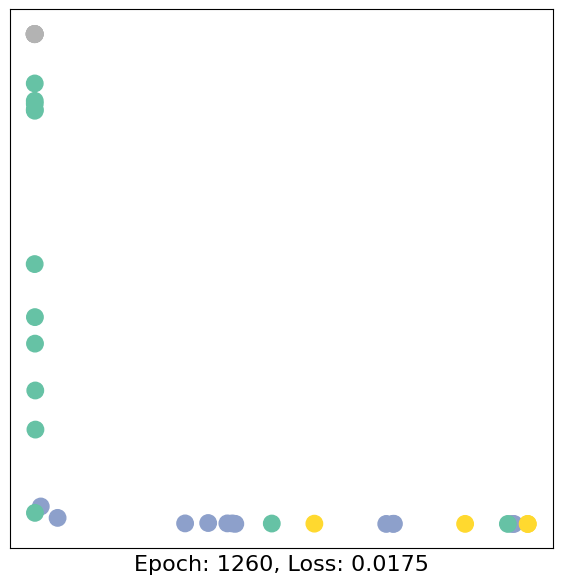

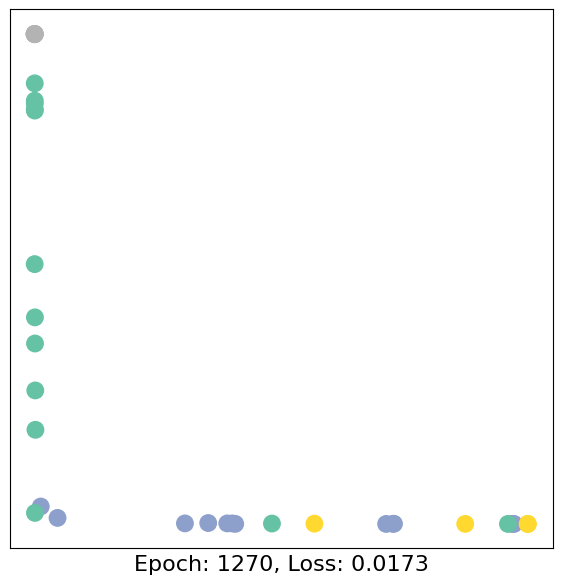

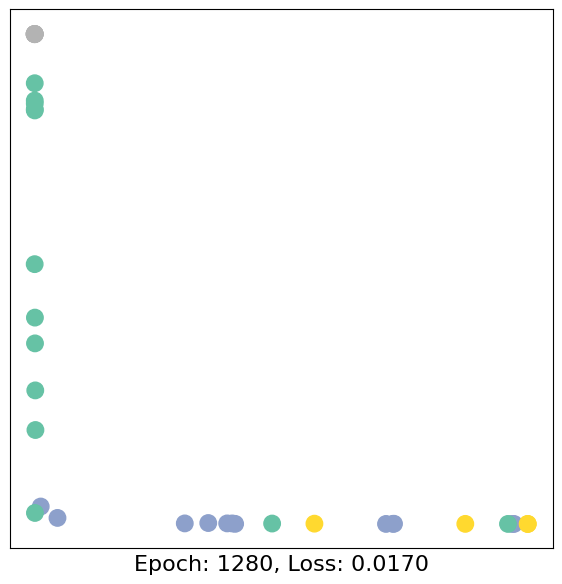

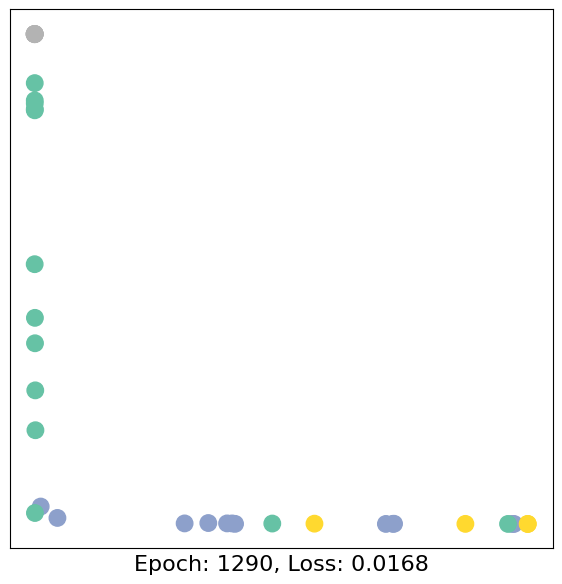

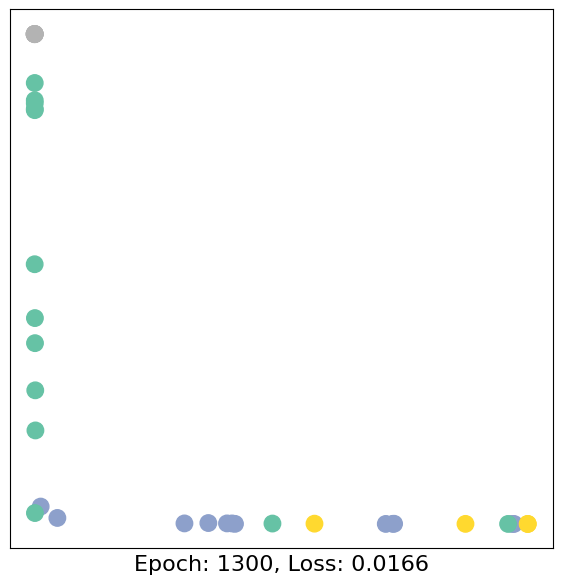

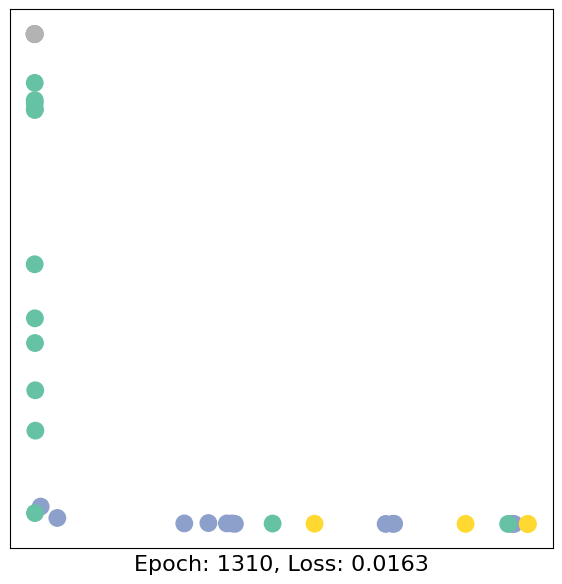

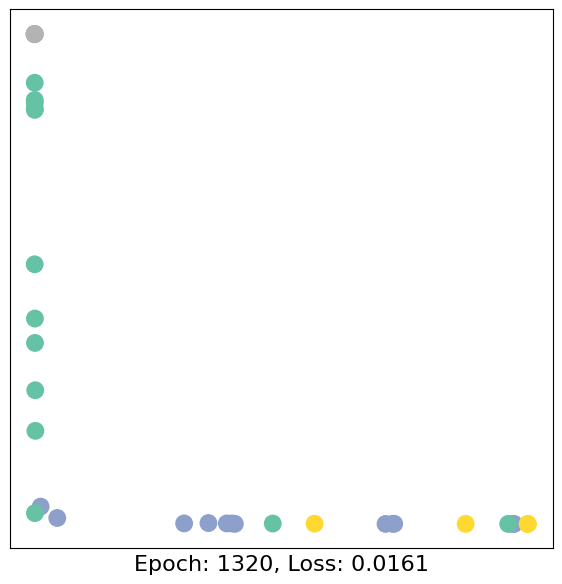

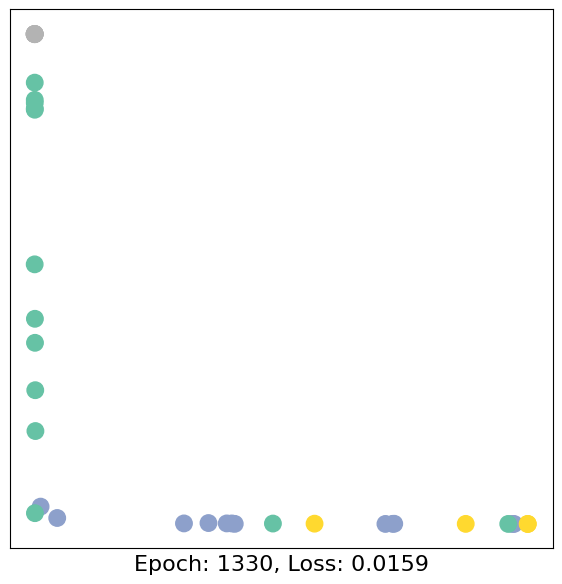

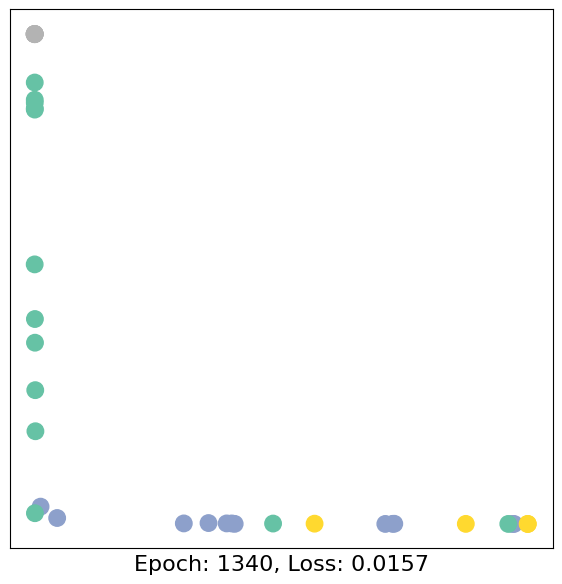

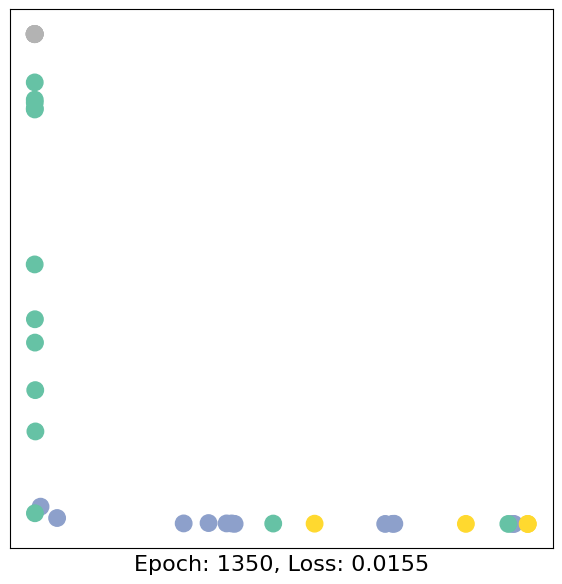

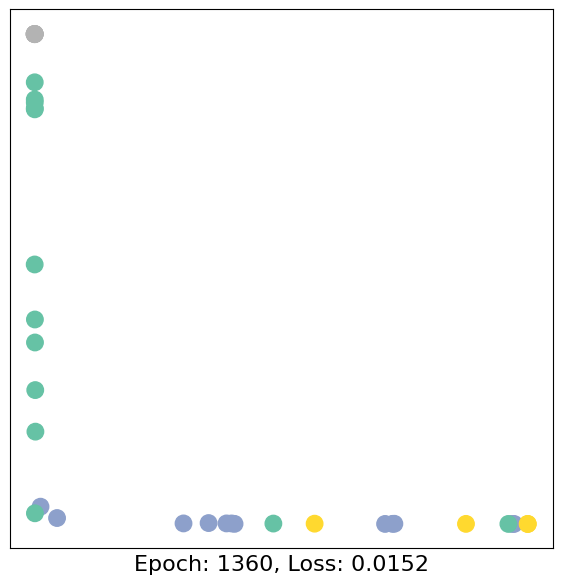

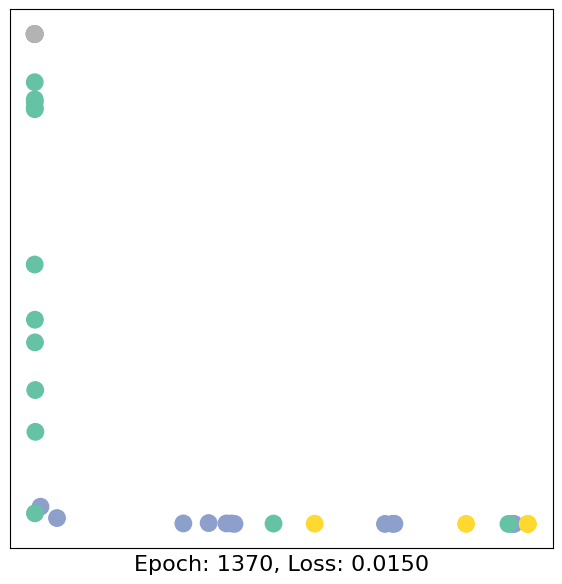

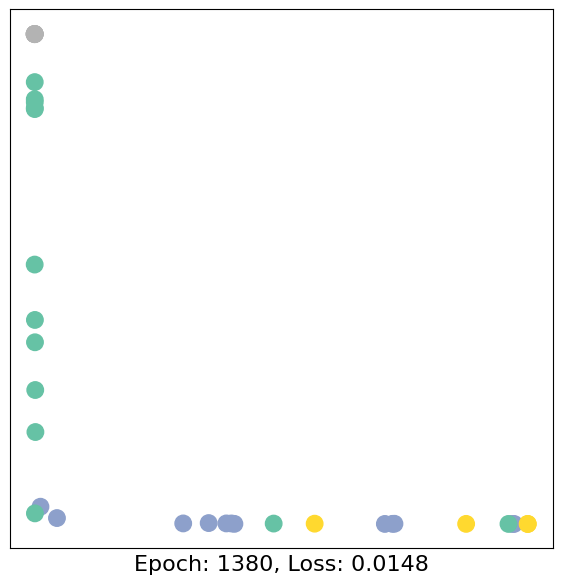

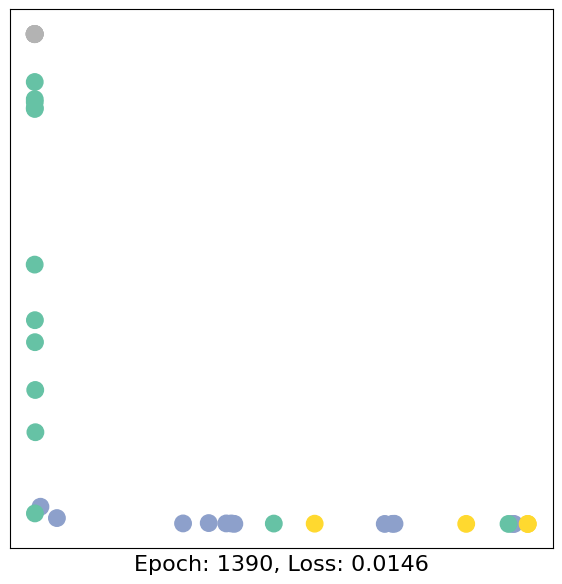

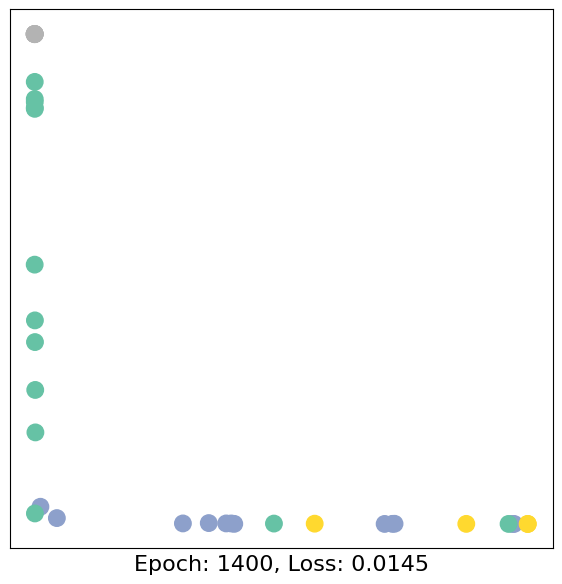

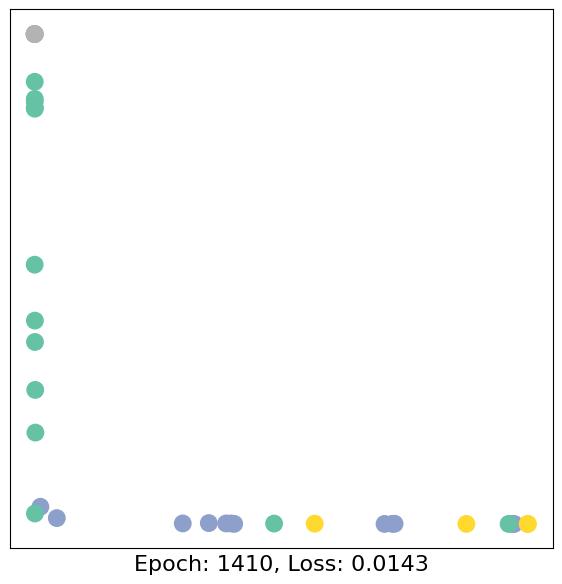

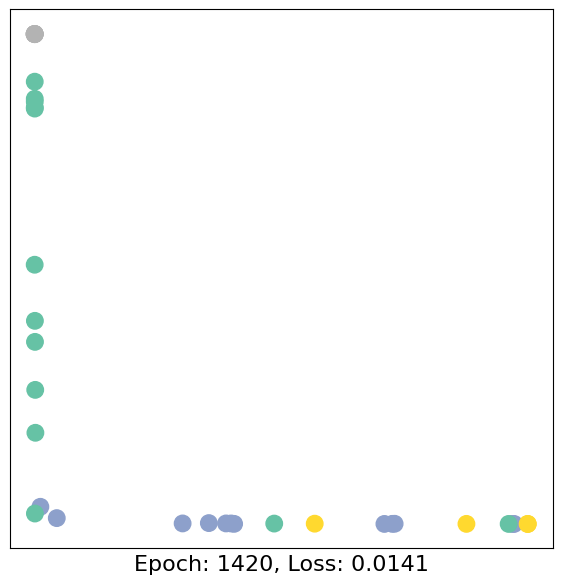

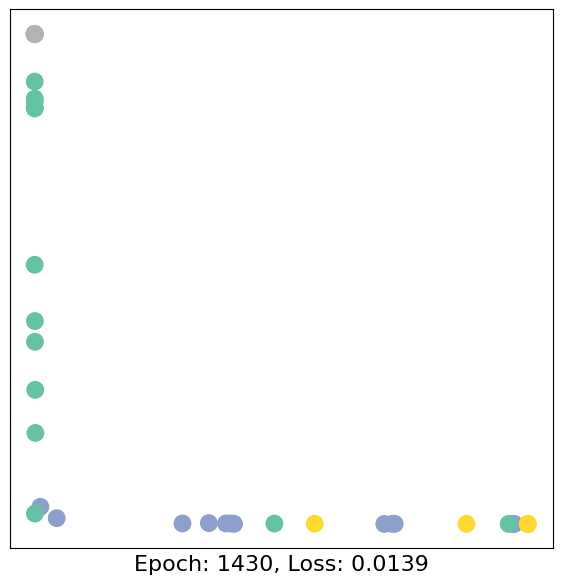

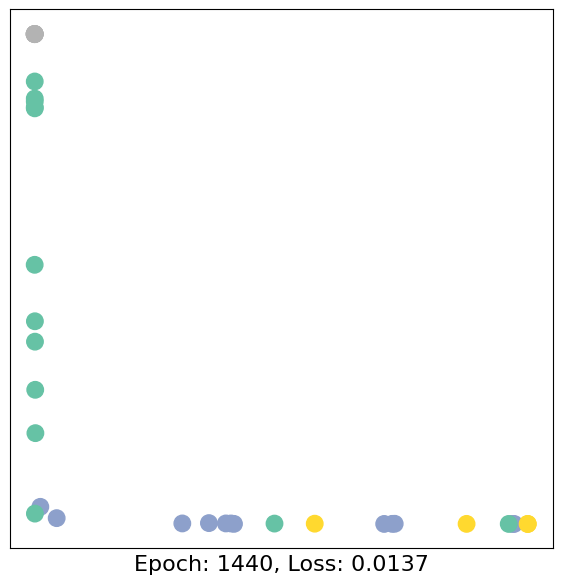

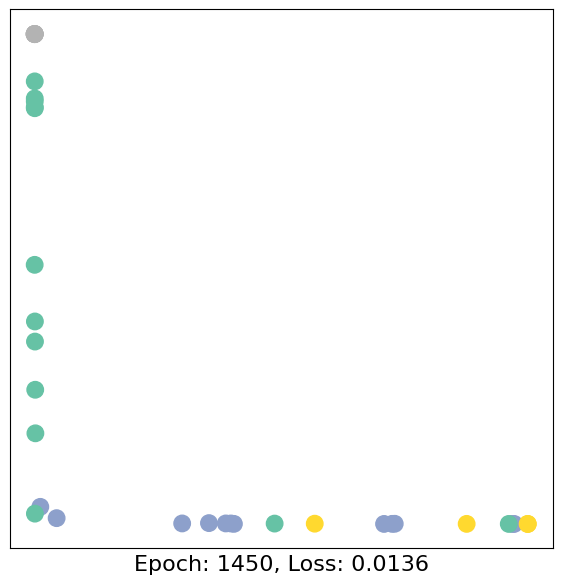

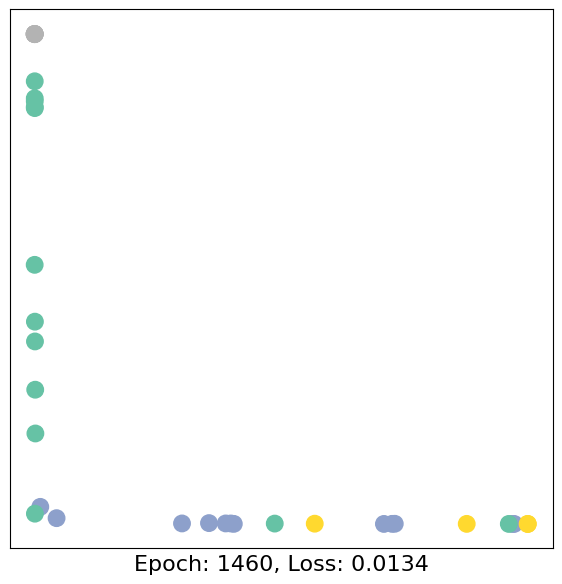

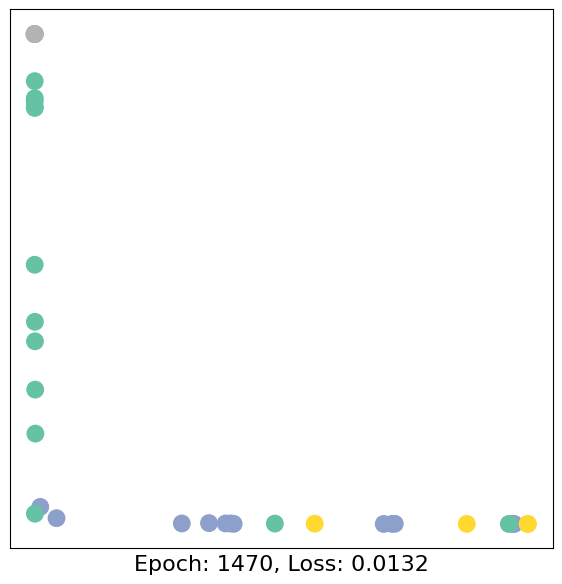

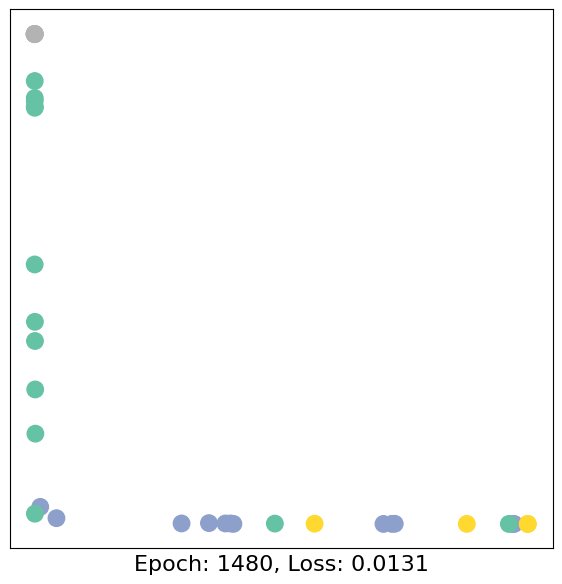

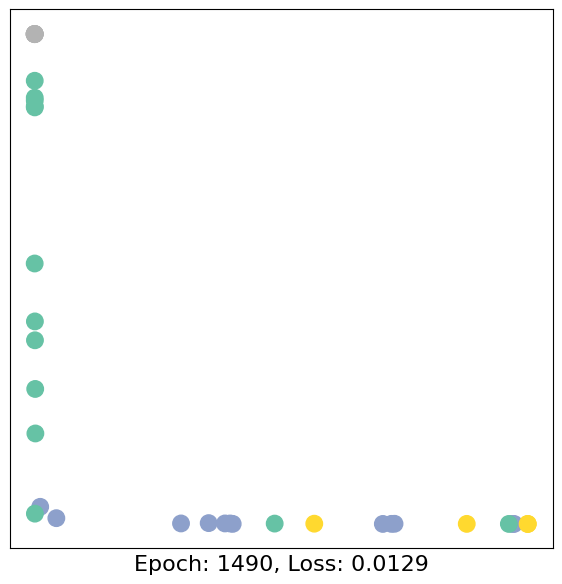

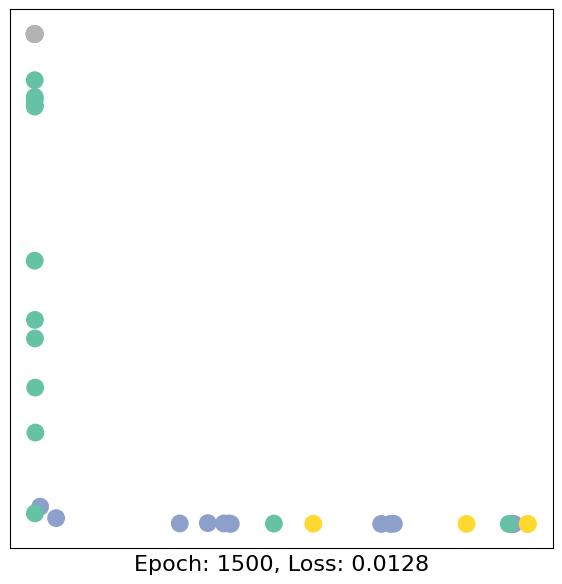

In [11]:
import time
# Step 6: Build the Model
# 1. Creating a FeedForwardNetwork
# 1.1 Structure (Architecture) of NN
class GCN(torch.nn.Module):
    def __init__(self):
        super(GCN, self).__init__()
        torch.manual_seed(12345)
        self.conv1 = GCNConv(dataset.num_features, 4)
        self.conv2 = GCNConv(4, 4)
        self.conv3 = GCNConv(4, 2)
        self.classifier = Linear(2, dataset.num_classes)

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index)
        h = h.tanh()
        h = self.conv2(h, edge_index)
        h = h.tanh()
        h = self.conv3(h, edge_index)
        h = h.tanh()  # Final GNN embedding space.

        # Apply a final (linear) classifier.
        out = self.classifier(h)

        return out, h

model = GCN()

# 1.2 Loss Function
criterion = torch.nn.CrossEntropyLoss()  # Define loss criterion.

# 1.3 Optmization Approch
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # Define optimizer.

for epoch in range(1501):
    optimizer.zero_grad()  # Clear gradients.
    # 2. Forward Pass
    out, h = model(data.x, data.edge_index)  # Perform a single forward pass.
    # 3. FeedForward Evaluation
    loss = criterion(out[data.train_mask], data.y[data.train_mask])  # Compute the loss solely based on the training nodes.
    # 4. Backward Pass / Gradient Calculation
    loss.backward()  # Derive gradients.
    # 5. Back Propagation / Update Weights
    optimizer.step()  # Update parameters based on gradients.    # Visualize the node embeddings every 10 epochs
    if epoch % 10 == 0:
        visualize(h, color=data.y, epoch=epoch, loss=loss)
        time.sleep(0.3)

As one can see, our 3-layer GCN model manages to linearly separating the communities and classifying most of the nodes correctly.

Furthermore, we did this all with a few lines of code, thanks to the PyTorch Geometric library which helped us out with data handling and GNN implementations.


## Documentation



You can explore more PyG functions through its [documentation](https://pytorch-geometric.readthedocs.io/en/latest/).